In [ ]:

# CELL 1
# Imports


import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import time
from tqdm import tqdm

from scipy.integrate import cumulative_trapezoid
from itertools import product , combinations
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from scipy.integrate import solve_ivp
from scipy.stats import qmc
from tqdm.auto import tqdm
from google.colab import drive
from matplotlib.lines import Line2D
from sklearn.metrics import mean_squared_error, r2_score

drive.mount('/content/drive')
# ------------------------------------------------------------
# Save directory

SAVE_DIR = "/content/drive/MyDrive/Forward_PI_DeepONet"

os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)
# ------------------------------------------------------------
# Random Seed
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

print("Seed =", seed)

Mounted at /content/drive
Device : cuda
Seed = 42


In [ ]:

# CELL 2 (

# Constants
R = 8.314
T0 = 273.15
N_TIME = 300
TIME_MAX = 200
t_grid = np.linspace(0, TIME_MAX, N_TIME)

# Parameter grids
logA_values = np.linspace(10, 17, 6)
E_values = np.linspace(180e3, 360e3, 6)
c_values = np.linspace(0.10, 0.80, 6)
beta_values = np.arange(3, 31, 2)

def compute_alpha_fast(t, beta, A, E, c):
    T = T0 + beta * t
    alpha_total = np.zeros_like(t)
    for Ai, Ei, ci in zip(A, E, c):
        k = Ai * np.exp(-Ei / (R * T))
        integ = cumulative_trapezoid(k, t, initial=0)
        alpha_i = 1 - np.exp(-integ)
        alpha_total += ci * alpha_i
    return np.clip(alpha_total, 0, 1)


# PRE-FILTER: Build reactions list (ONCE)

print("Building reactions list...")

all_params = []
for logA, E in product(logA_values, E_values):
    for c in c_values:
        if c >= 0.05:
            all_params.append((logA, E, c))

all_params = sorted(all_params, key=lambda x: x[1])
print(f"Total param combos: {len(all_params)}")

reactions = []

for p1, p2, p3 in combinations(all_params, 3):
    # Canonical order: component 1 < component 2 < component 3 by E
    comps = sorted([p1, p2, p3], key=lambda x: x[1])

    logA = np.array([p[0] for p in comps], dtype=np.float32)
    E = np.array([p[1] for p in comps], dtype=np.float32)
    c = np.array([p[2] for p in comps], dtype=np.float32)

    if abs(E[0] - E[1]) < 30000 or abs(E[1] - E[2]) < 30000:
        continue

    total_c = c.sum()
    if abs(total_c - 1.0) > 0.01:
        continue

    c = c / total_c
    A = 10 ** logA

    reactions.append({
        "A": A,
        "E": E,
        "c": c,
        "logA": logA,
        "E_kJ": E / 1000.0,
    })

print(f"Valid canonical reactions: {len(reactions)}")


# Generate curves (ONLY for valid reactions)

print("Generating curves...")

branch_input = []
trunk_input = []
alpha_output = []
count = 0
skipped = 0

for r in tqdm(reactions):
    A = r['A']
    E = r['E']
    c = r['c']

    branch = np.array([
        r['logA'][0], r['E_kJ'][0], r['c'][0],
        r['logA'][1], r['E_kJ'][1], r['c'][1],
        r['logA'][2], r['E_kJ'][2], r['c'][2],
    ], dtype=np.float32)

    for beta in beta_values:
        alpha = compute_alpha_fast(t_grid, beta, A, E, c)
        alpha = np.clip(alpha, 0, 1)
        if alpha[-1] < 0.99:
            skipped += 1
            continue
        trunk = np.column_stack([t_grid, np.full_like(t_grid, beta)])
        branch_input.append(branch)
        trunk_input.append(trunk.astype(np.float32))
        alpha_output.append(alpha.astype(np.float32))
        count += 1

# Convert and save
branch_input = np.asarray(branch_input, dtype=np.float32)
trunk_input = np.asarray(trunk_input, dtype=np.float32)
alpha_output = np.asarray(alpha_output, dtype=np.float32)

print()
print(f"Generated: {count}")
print(f"Skipped: {skipped}")
print(f"Branch: {branch_input.shape}")
print(f"Trunk: {trunk_input.shape}")
print(f"Alpha: {alpha_output.shape}")

OUT_PATH = os.path.join(SAVE_DIR, "forward_dataset_canonical.npz")
np.savez_compressed(
    OUT_PATH,
    branch=branch_input,
    trunk=trunk_input,
    alpha=alpha_output,
    t=t_grid
)

print("Dataset saved to:", OUT_PATH)
print("Saved branch shape:", branch_input.shape)

Building reactions list...
Total param combos: 216
Valid canonical reactions: 90720
Generating curves...


  0%|          | 0/90720 [00:00<?, ?it/s]


Generated: 1121280
Skipped: 148800
Branch: (1121280, 9)
Trunk: (1121280, 300, 2)
Alpha: (1121280, 300)
Dataset saved to: /content/drive/MyDrive/Forward_PI_DeepONet/forward_dataset_canonical.npz
Saved branch shape: (1121280, 9)


In [ ]:

# CELL 3
# Forward DeepONet

class ForwardDeepONet(nn.Module):

    def __init__(
        self,
        branch_dim=9,
        trunk_dim=2,
        hidden=256,
        basis_dim=128
    ):

        super().__init__()


        # Branch Network
        self.branch = nn.Sequential(

            nn.Linear(branch_dim, hidden),
            nn.GELU(),

            nn.Linear(hidden, hidden),
            nn.GELU(),

            nn.Linear(hidden, hidden),
            nn.GELU(),

            nn.Linear(hidden, basis_dim)

        )


        # Trunk Network

        self.trunk = nn.Sequential(

            nn.Linear(trunk_dim, hidden),
            nn.GELU(),

            nn.Linear(hidden, hidden),
            nn.GELU(),

            nn.Linear(hidden, hidden),
            nn.GELU(),

            nn.Linear(hidden, basis_dim)

        )

        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, branch, trunk):

        b = self.branch(branch)

        batch_size, n_points, _ = trunk.shape

        trunk = trunk.reshape(-1,2)

        t = self.trunk(trunk)

        t = t.reshape(batch_size,n_points,-1)


        # DeepONet inner product

        y = torch.einsum(

            "bi,bni->bn",

            b,
            t

        )

        y = y.unsqueeze(-1)

        return torch.sigmoid(

            y + self.bias

        )

-
# Build model

model = ForwardDeepONet().to(device)

print(model)

print()

print(

    "Trainable Parameters:",

    sum(

        p.numel()

        for p in model.parameters()

    )

)

ForwardDeepONet(
  (branch): Sequential(
    (0): Linear(in_features=9, out_features=256, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=256, out_features=128, bias=True)
  )
  (trunk): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=256, out_features=128, bias=True)
  )
)

Trainable Parameters: 332289


In [ ]:

# CELL 4

# Train/Test Split

(
    branch_train,
    branch_test,
    trunk_train,
    trunk_test,
    alpha_train,
    alpha_test,
) = train_test_split(
    branch_input,
    trunk_input,
    alpha_output,
    test_size=0.10,
    random_state=42,
    shuffle=True
)

print(f"Training operators : {len(branch_train)}")
print(f"Testing operators  : {len(branch_test)}")

# ------------------------------------------------------------
# Normalize Branch
branch_mean = branch_train.mean(axis=0)
branch_std = branch_train.std(axis=0) + 1e-8

branch_train = (branch_train - branch_mean) / branch_std
branch_test = (branch_test - branch_mean) / branch_std

# ------------------------------------------------------------
# Normalize Trunk
trunk_mean = trunk_train.mean(axis=(0, 1))
trunk_std = trunk_train.std(axis=(0, 1)) + 1e-8

trunk_train = (trunk_train - trunk_mean) / trunk_std
trunk_test = (trunk_test - trunk_mean) / trunk_std

# ------------------------------------------------------------
# Save statistics
np.save(os.path.join(SAVE_DIR, "branch_mean.npy"), branch_mean)
np.save(os.path.join(SAVE_DIR, "branch_std.npy"), branch_std)
np.save(os.path.join(SAVE_DIR, "trunk_mean.npy"), trunk_mean)
np.save(os.path.join(SAVE_DIR, "trunk_std.npy"), trunk_std)
print("Normalization statistics saved.")

# ============================================================
# SAVE ALL PROCESSED DATA (After Normalization)
print("\nSaving processed data to Drive...")

np.savez_compressed(
    os.path.join(SAVE_DIR, "processed_data.npz"),
    branch_train=branch_train,
    trunk_train=trunk_train,
    alpha_train=alpha_train,
    branch_test=branch_test,
    trunk_test=trunk_test,
    alpha_test=alpha_test,
    branch_mean=branch_mean,
    branch_std=branch_std,
    trunk_mean=trunk_mean,
    trunk_std=trunk_std,
    t_grid=t_grid
)

print(f"✅ Processed data saved to: {os.path.join(SAVE_DIR, 'processed_data.npz')}")

# ============================================================
# Dataset (Data Already on GPU)
class ForwardDataset(Dataset):
    def __init__(self, branch, trunk, alpha):
        self.branch = torch.tensor(branch, dtype=torch.float32, device=device)
        self.trunk = torch.tensor(trunk, dtype=torch.float32, device=device)
        self.alpha = torch.tensor(alpha, dtype=torch.float32, device=device)

    def __len__(self):
        return len(self.branch)

    def __getitem__(self, idx):
        return self.branch[idx], self.trunk[idx], self.alpha[idx]

# ============================================================
# Dataset Objects=
train_dataset = ForwardDataset(branch_train, trunk_train, alpha_train)
test_dataset = ForwardDataset(branch_test, trunk_test, alpha_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=4096,
    shuffle=True,
    pin_memory=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4096,
    shuffle=False,
    pin_memory=False,
    num_workers=0
)

print()
print(f"Train batches : {len(train_loader)}")
print(f"Test batches  : {len(test_loader)}")
print()
print(f"Branch device : {train_dataset.branch.device}")
print(f"Trunk device  : {train_dataset.trunk.device}")
print(f"Alpha device  : {train_dataset.alpha.device}")
print()
print(f"Branch shape  : {branch_train.shape}")
print(f"Trunk shape   : {trunk_train.shape}")
print(f"Alpha shape   : {alpha_train.shape}")
print()
print(f"GPU Memory used: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

Device: cuda
Training operators : 6054912
Testing operators  : 672768
Normalization statistics saved.

Saving processed data to Drive...
✅ Processed data saved to: /content/drive/MyDrive/PI_DeepONet_Checkpoints/processed_data.npz

Train batches : 1479
Test batches  : 165

Branch device : cuda:0
Trunk device  : cuda:0
Alpha device  : cuda:0

Branch shape  : (6054912, 9)
Trunk shape   : (6054912, 300, 2)
Alpha shape   : (6054912, 300)

GPU Memory used: 24.47 GB


In [ ]:



# 3. Create Dataset (fast - just wrap tensors)

class ForwardDataset(Dataset):
    def __init__(self, branch, trunk, alpha):
        # Keep data on CPU as NumPy arrays or torch tensors on CPU
        self.branch = torch.tensor(branch, dtype=torch.float32)  # No 'device' arg
        self.trunk = torch.tensor(trunk, dtype=torch.float32)
        self.alpha = torch.tensor(alpha, dtype=torch.float32)

    def __len__(self):
        return len(self.branch)

    def __getitem__(self, idx):
        # Move individual samples to GPU only when requested
        return (self.branch[idx].to(device),
                self.trunk[idx].to(device),
                self.alpha[idx].to(device))

train_dataset = ForwardDataset(branch_train, trunk_train, alpha_train)
test_dataset = ForwardDataset(branch_test, trunk_test, alpha_test)

# In your resume Cell 6, change:
train_loader = DataLoader(
    train_dataset,
    batch_size=4096,
    shuffle=True,
    pin_memory=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4096,
    shuffle=False,
    pin_memory=False,
    num_workers=0
)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Loaded 6054912 training samples, 672768 test samples
Train batches: 1479
Test batches: 165


In [ ]:

# CELL 6
# Train Physics-Informed Forward DeepONet
# Data loss + DAEM residual loss + initial condition loss


criterion = nn.MSELoss()

branch_mean_t = torch.tensor(branch_mean, dtype=torch.float32, device=device)
branch_std_t  = torch.tensor(branch_std, dtype=torch.float32, device=device)

trunk_mean_t = torch.tensor(trunk_mean, dtype=torch.float32, device=device)
trunk_std_t  = torch.tensor(trunk_std, dtype=torch.float32, device=device)

def daem_residual_loss(alpha_pred, branch_norm, trunk_norm):
    R = 8.314
    T0 = 273.15

    alpha_pred = alpha_pred.squeeze(-1)

    branch_phys = branch_norm * branch_std_t + branch_mean_t
    trunk_phys = trunk_norm * trunk_std_t + trunk_mean_t

    t = trunk_phys[:, :, 0]
    beta = trunk_phys[:, :, 1]

    logA = branch_phys[:, [0, 3, 6]]
    E = branch_phys[:, [1, 4, 7]] * 1000.0
    c = branch_phys[:, [2, 5, 8]]

    A = 10.0 ** logA

    T = T0 + beta.unsqueeze(-1) * t.unsqueeze(-1)

    A = A.unsqueeze(1)
    E = E.unsqueeze(1)
    c = c.unsqueeze(1)

    k = A * torch.exp(-E / (R * T))

    dt = t[:, 1:] - t[:, :-1]

    k_avg = 0.5 * (k[:, 1:, :] + k[:, :-1, :])
    integ_step = k_avg * dt.unsqueeze(-1)
    integ = torch.cumsum(integ_step, dim=1)

    zero = torch.zeros_like(integ[:, :1, :])
    integ = torch.cat([zero, integ], dim=1)

    alpha_i = 1.0 - torch.exp(-integ)
    alpha_daem = torch.sum(c * alpha_i, dim=-1)

    dalpha_dt_pred = (alpha_pred[:, 1:] - alpha_pred[:, :-1]) / (dt + 1e-8)
    dalpha_dt_daem = (alpha_daem[:, 1:] - alpha_daem[:, :-1]) / (dt + 1e-8)

    residual = dalpha_dt_pred - dalpha_dt_daem

    return torch.mean(residual ** 2)


def initial_condition_loss(alpha_pred):
    alpha0_pred = alpha_pred[:, 0, :]
    alpha0_true = torch.zeros_like(alpha0_pred)
    return criterion(alpha0_pred, alpha0_true)


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=10
)

CHECKPOINT = os.path.join(SAVE_DIR, "ForwardDeepONet_PI.pt")

start_epoch = 0
best_val_loss = np.inf

train_losses = []
val_losses = []

train_data_losses = []
train_phys_losses = []
train_ic_losses = []

val_data_losses = []
val_phys_losses = []
val_ic_losses = []

if os.path.exists(CHECKPOINT):
    ckpt = torch.load(CHECKPOINT, map_location=device)

    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])

    start_epoch = ckpt["epoch"]
    best_val_loss = ckpt["best_val_loss"]

    train_losses = ckpt["train_losses"]
    val_losses = ckpt["val_losses"]

    train_data_losses = ckpt.get("train_data_losses", [])
    train_phys_losses = ckpt.get("train_phys_losses", [])
    train_ic_losses = ckpt.get("train_ic_losses", [])

    val_data_losses = ckpt.get("val_data_losses", [])
    val_phys_losses = ckpt.get("val_phys_losses", [])
    val_ic_losses = ckpt.get("val_ic_losses", [])

    print("Checkpoint Loaded")
    print("Resume Epoch:", start_epoch)

else:
    print("Training From Scratch")

EPOCHS = 11

lambda_phys = 1e-5
lambda_ic = 0.1

epoch_times = []
total_start_time = time.time()

for epoch in range(start_epoch, EPOCHS):

    epoch_start_time = time.time()

    model.train()

    running_train = 0.0
    running_train_data = 0.0
    running_train_phys = 0.0
    running_train_ic = 0.0

    for branch_batch, trunk_batch, alpha_batch in train_loader:

        branch_batch = branch_batch.to(device)
        trunk_batch = trunk_batch.to(device)
        alpha_batch = alpha_batch.to(device).unsqueeze(-1)

        optimizer.zero_grad(set_to_none=True)

        prediction = model(branch_batch, trunk_batch)

        loss_data = criterion(prediction, alpha_batch)
        loss_phys = daem_residual_loss(prediction, branch_batch, trunk_batch)
        loss_ic = initial_condition_loss(prediction)

        loss = (
            loss_data
            + lambda_phys * loss_phys
            + lambda_ic * loss_ic
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        running_train += loss.item()
        running_train_data += loss_data.item()
        running_train_phys += loss_phys.item()
        running_train_ic += loss_ic.item()

    train_loss = running_train / len(train_loader)
    train_data_loss = running_train_data / len(train_loader)
    train_phys_loss = running_train_phys / len(train_loader)
    train_ic_loss = running_train_ic / len(train_loader)

    model.eval()

    running_val = 0.0
    running_val_data = 0.0
    running_val_phys = 0.0
    running_val_ic = 0.0

    with torch.no_grad():

        for branch_batch, trunk_batch, alpha_batch in test_loader:

            branch_batch = branch_batch.to(device)
            trunk_batch = trunk_batch.to(device)
            alpha_batch = alpha_batch.to(device).unsqueeze(-1)

            prediction = model(branch_batch, trunk_batch)

            loss_data = criterion(prediction, alpha_batch)
            loss_phys = daem_residual_loss(prediction, branch_batch, trunk_batch)
            loss_ic = initial_condition_loss(prediction)

            loss = (
                loss_data
                + lambda_phys * loss_phys
                + lambda_ic * loss_ic
            )

            running_val += loss.item()
            running_val_data += loss_data.item()
            running_val_phys += loss_phys.item()
            running_val_ic += loss_ic.item()

    val_loss = running_val / len(test_loader)
    val_data_loss = running_val_data / len(test_loader)
    val_phys_loss = running_val_phys / len(test_loader)
    val_ic_loss = running_val_ic / len(test_loader)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_data_losses.append(train_data_loss)
    train_phys_losses.append(train_phys_loss)
    train_ic_losses.append(train_ic_loss)

    val_data_losses.append(val_data_loss)
    val_phys_losses.append(val_phys_loss)
    val_ic_losses.append(val_ic_loss)

    epoch_time = time.time() - epoch_start_time
    epoch_times.append(epoch_time)

    lr = optimizer.param_groups[0]["lr"]

    if epoch  % 1 == 0 or epoch == 0:
        print(
            f"Epoch {epoch+1:4d}/{EPOCHS} | "
            f"Train = {train_loss:.8f} | "
            f"Val = {val_loss:.8f} | "
            f"Data = {val_data_loss:.8f} | "
            f"Phys = {val_phys_loss:.8e} | "
            f"IC = {val_ic_loss:.8e} | "
            f"LR = {lr:.2e} | "
            f"Time = {epoch_time:.1f}s"
        )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            {
                "epoch": epoch,
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "best_val_loss": best_val_loss,
                "lambda_phys": lambda_phys,
                "lambda_ic": lambda_ic,
                "train_losses": train_losses,
                "val_losses": val_losses,
                "train_data_losses": train_data_losses,
                "train_phys_losses": train_phys_losses,
                "train_ic_losses": train_ic_losses,
                "val_data_losses": val_data_losses,
                "val_phys_losses": val_phys_losses,
                "val_ic_losses": val_ic_losses,
            },
            CHECKPOINT
        )

        print("Best PI Forward Model Saved")

print()
print("Training Finished")
print("Best Validation Loss =", best_val_loss)

np.save(os.path.join(SAVE_DIR, "pi_train_losses.npy"), np.array(train_losses))
np.save(os.path.join(SAVE_DIR, "pi_val_losses.npy"), np.array(val_losses))
np.save(os.path.join(SAVE_DIR, "pi_train_data_losses.npy"), np.array(train_data_losses))
np.save(os.path.join(SAVE_DIR, "pi_train_phys_losses.npy"), np.array(train_phys_losses))
np.save(os.path.join(SAVE_DIR, "pi_train_ic_losses.npy"), np.array(train_ic_losses))
np.save(os.path.join(SAVE_DIR, "pi_val_data_losses.npy"), np.array(val_data_losses))
np.save(os.path.join(SAVE_DIR, "pi_val_phys_losses.npy"), np.array(val_phys_losses))
np.save(os.path.join(SAVE_DIR, "pi_val_ic_losses.npy"), np.array(val_ic_losses))

Checkpoint Loaded
Resume Epoch: 9
Epoch   10/11 | Train = 0.00008057 | Val = 0.00006841 | Data = 0.00006840 | Phys = 2.60761941e-05 | IC = 8.48409703e-08 | LR = 1.00e-03 | Time = 667.7s
Best PI Forward Model Saved
Epoch   11/11 | Train = 0.00016327 | Val = 0.00007644 | Data = 0.00007644 | Phys = 2.97275093e-05 | IC = 6.90540482e-16 | LR = 1.00e-03 | Time = 665.9s

Training Finished
Best Validation Loss = 6.841266193518866e-05


Model loaded in 0.00s
Model device: cuda:0
Generating predictions for error analysis...
predictions: (500, 300)
targets    : (500, 300)

Generating test predictions...
predictions: (5000, 300)
targets    : (5000, 300)

Performance Metrics
Test Set
MSE             : 6.82295358e-05
RMSE            : 8.26011718e-03
R²              : 0.999567
L2 Relative Err : 9.85605828e-03



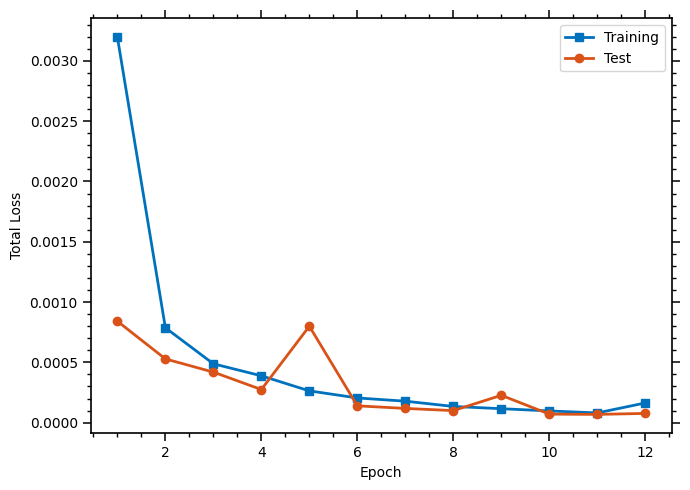

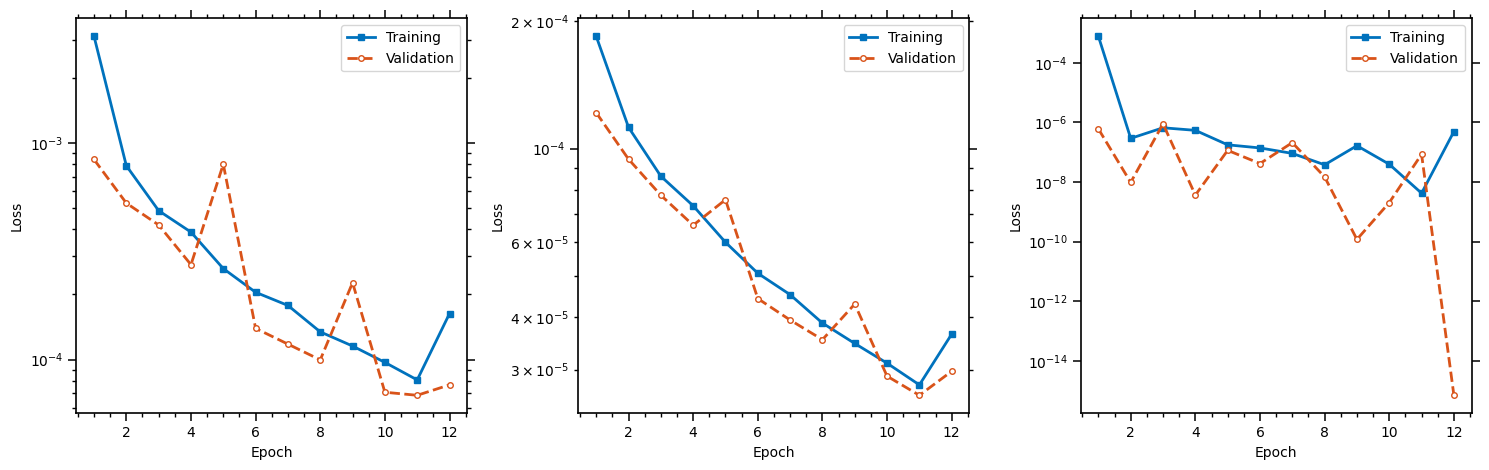

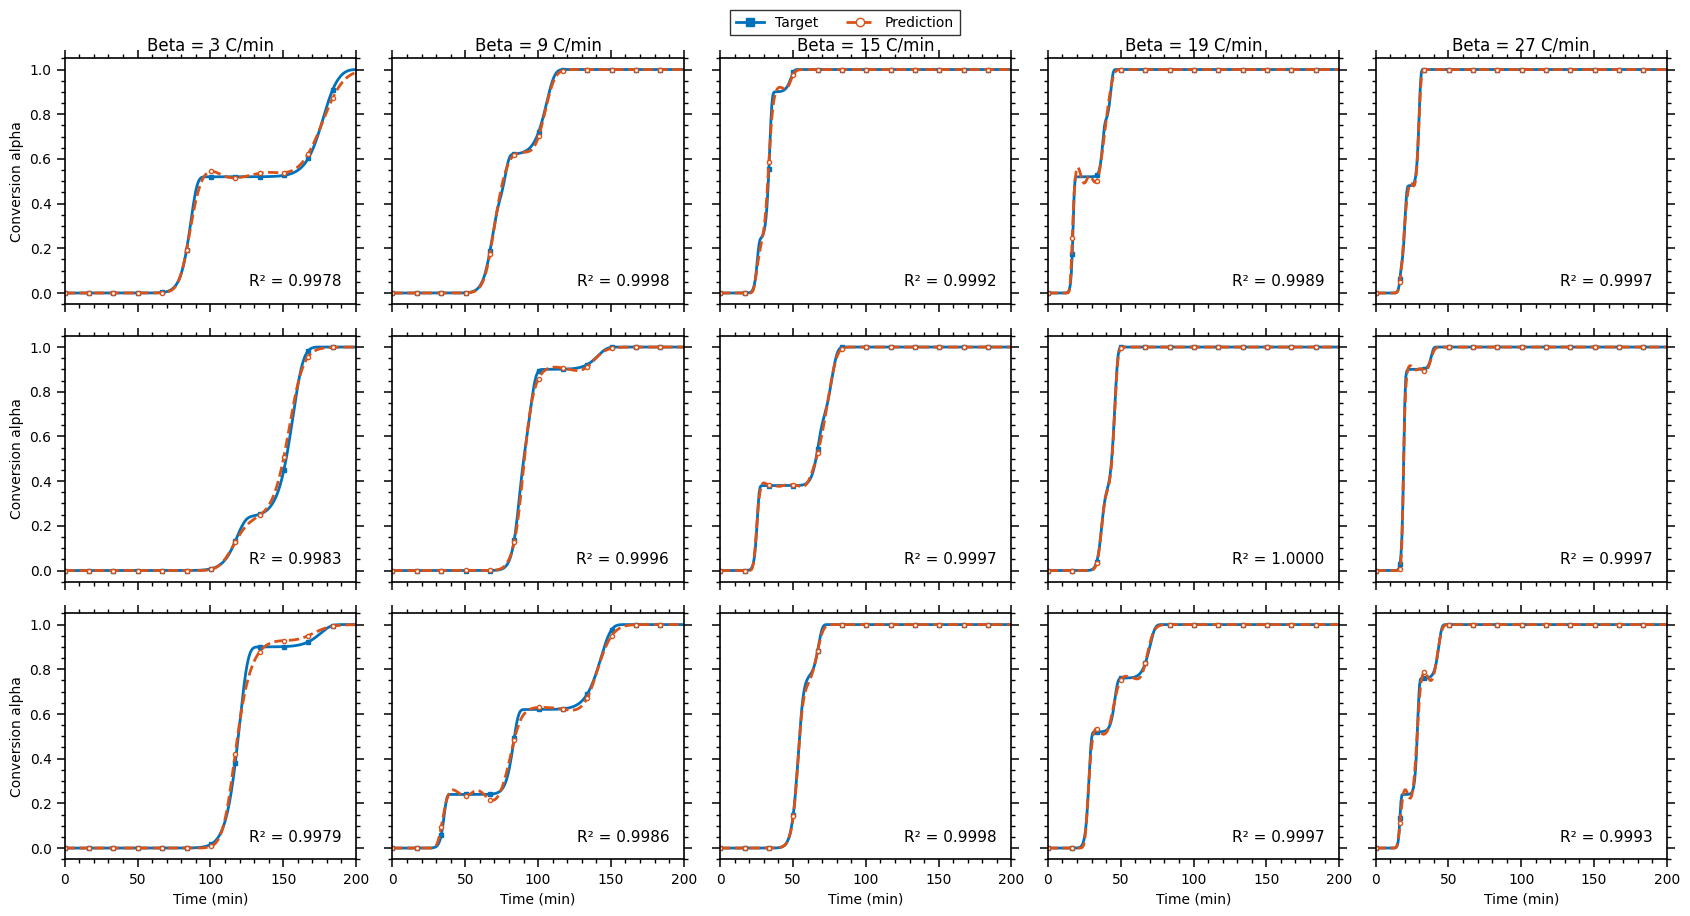

Generating training predictions for parity plot...
Generating test predictions for parity plot...
val_loader not found. Validation parity skipped.


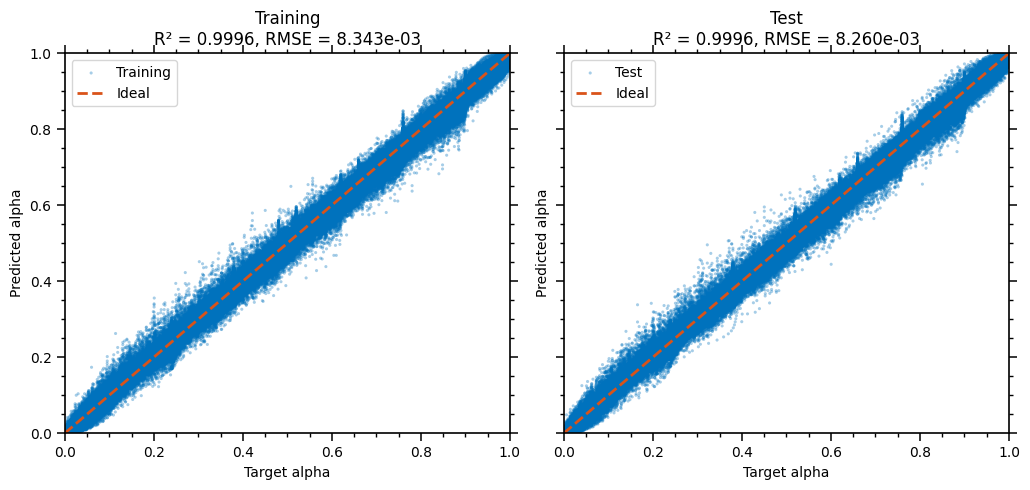

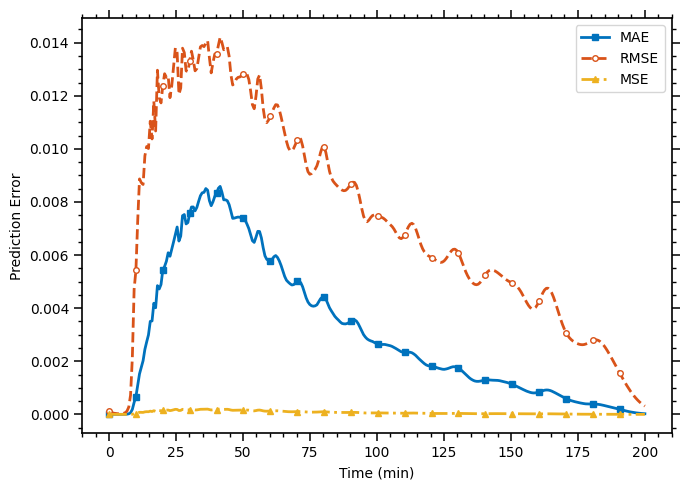


Evaluation Complete
Time taken: 82.04s
Figures saved to: /content/drive/MyDrive/PI_DeepONet_Checkpoints


In [ ]:

# CELL 7a: ORIGIN-LIKE Forward DeepONet Evaluation


start_time = time.time()

model = forward_model
model = model.to(device)
model.eval()

print(f"Model loaded in {time.time() - start_time:.2f}s")
print(f"Model device: {next(model.parameters()).device}")

# Generate predictions and targets
num_samples_to_plot = 500

predictions = []
targets = []
seen = 0

print("Generating predictions for error analysis...")

with torch.no_grad():
    for branch_batch, trunk_batch, alpha_batch in test_loader:

        branch_batch = branch_batch.to(device)
        trunk_batch = trunk_batch.to(device)
        alpha_batch = alpha_batch.to(device)

        pred = model(branch_batch, trunk_batch)

        predictions.append(pred.squeeze(-1).cpu().numpy())
        targets.append(alpha_batch.cpu().numpy())

        seen += alpha_batch.shape[0]

        if seen >= num_samples_to_plot:
            break

predictions = np.concatenate(predictions, axis=0)[:num_samples_to_plot]
targets = np.concatenate(targets, axis=0)[:num_samples_to_plot]

print("predictions:", predictions.shape)
print("targets    :", targets.shape)

# Helper functions

def origin_axes(ax):
    ax.grid(False)

    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.2)
        ax.spines[side].set_color("black")

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=6,
        width=1.1,
        top=True,
        right=True
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="out",
        length=3,
        width=1.0,
        top=True,
        right=True
    )

    ax.minorticks_on()


def l2_relative_error(y_true, y_pred):
    num = np.linalg.norm((y_pred - y_true).reshape(-1), ord=2)
    den = np.linalg.norm(y_true.reshape(-1), ord=2) + 1e-12
    return num / den


def evaluate_loader(loader, max_samples=5000):
    preds = []
    trues = []
    betas = []
    trunks = []
    seen = 0

    with torch.no_grad():
        for branch_batch, trunk_batch, alpha_batch in loader:

            branch_batch = branch_batch.to(device)
            trunk_batch_gpu = trunk_batch.to(device)
            alpha_batch_gpu = alpha_batch.to(device)

            pred = model(branch_batch, trunk_batch_gpu)

            pred_np = pred.squeeze(-1).detach().cpu().numpy()
            true_np = alpha_batch_gpu.detach().cpu().numpy()
            trunk_np = trunk_batch.detach().cpu().numpy()

            preds.append(pred_np)
            trues.append(true_np)
            trunks.append(trunk_np)

            if "trunk_mean" in globals() and "trunk_std" in globals():
                trunk_phys = trunk_np * trunk_std + trunk_mean
                beta_np = np.round(trunk_phys[:, :, 1].mean(axis=1), 6)
            else:
                beta_np = np.round(trunk_np[:, :, 1].mean(axis=1), 6)

            betas.append(beta_np)

            seen += true_np.shape[0]

            if seen >= max_samples:
                break

    preds = np.concatenate(preds, axis=0)[:max_samples]
    trues = np.concatenate(trues, axis=0)[:max_samples]
    trunks = np.concatenate(trunks, axis=0)[:max_samples]
    betas = np.concatenate(betas, axis=0)[:max_samples]

    return preds, trues, trunks, betas


def print_metrics(name, y_true, y_pred):
    mse = mean_squared_error(y_true.flatten(), y_pred.flatten())
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true.flatten(), y_pred.flatten())
    l2 = l2_relative_error(y_true, y_pred)

    print(f"{name}")
    print(f"MSE             : {mse:.8e}")
    print(f"RMSE            : {rmse:.8e}")
    print(f"R²              : {r2:.6f}")
    print(f"L2 Relative Err : {l2:.8e}")
    print()

    return mse, rmse, r2, l2


# ------------------------------------------------------------
# Evaluate test set
# ------------------------------------------------------------
print("\nGenerating test predictions...")

predictions, targets, trunk_used, beta_used = evaluate_loader(
    test_loader,
    max_samples=5000
)

print("predictions:", predictions.shape)
print("targets    :", targets.shape)

print()
print("=" * 60)
print("Performance Metrics")
print("=" * 60)

test_metrics = print_metrics("Test Set", targets, predictions)


# # Figure 1: Learning Curves + L2 Relative Error

fig, ax = plt.subplots(figsize=(7, 5))

if "train_losses" in globals():
    ax.plot(
        np.arange(1, len(train_losses) + 1),
        train_losses,
        color="#0072BD",
        lw=2,
        marker="s",
        markevery=max(1, len(train_losses)//10),
        label="Training"
    )

if "val_losses" in globals():
    ax.plot(
        np.arange(1, len(val_losses) + 1),
        val_losses,
        color="#D95319",
        lw=2,
        marker="o",
        markevery=max(1, len(val_losses)//10),
        label="Test"
    )

ax.set_xlabel("Epoch")
ax.set_ylabel("Total Loss")
origin_axes(ax)
ax.legend(loc="best")

fig.tight_layout()
fig.savefig(
    os.path.join(SAVE_DIR, "learning_curves_origin.png"),
    dpi=600,
    bbox_inches="tight",
    transparent=False,
    facecolor="white"
)
plt.show()

==
# FORWARD PI: COMPONENT LOSS CURVES ONLY
# Data-Fitting, Physics-Residual, Initial-Condition


epochs = np.arange(1, len(train_data_losses) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

loss_plots = [
    ("Data-Fitting Loss", train_data_losses, val_data_losses),
    ("DAEM Physics-Residual Loss", train_phys_losses, val_phys_losses),
    ("Initial-Condition Constraint Loss", train_ic_losses, val_ic_losses),
]

for ax, (title, train_y, val_y) in zip(axes, loss_plots):

    ax.plot(
        epochs,
        train_y,
        color="#0072BD",
        lw=2,
        marker="s",
        markersize=4,
        markevery=1,
        label="Training"
    )

    ax.plot(
        epochs,
        val_y,
        color="#D95319",
        lw=2,
        ls="--",
        marker="o",
        markersize=4,
        markerfacecolor="white",
        markeredgecolor="#D95319",
        markevery=1,
        label="Validation"
    )

    #ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_yscale("log")

    origin_axes(ax)
    ax.legend(loc="best")

fig.tight_layout()

fig.savefig(
    os.path.join(SAVE_DIR, "forward_pi_component_losses_origin.png"),
    dpi=600,
    bbox_inches="tight",
    transparent=False,
    facecolor="white"
)

plt.show()

# Figure 2: Selected heating rates x 3 predictions
# Heating rates: 3, 10, 15, 20, 27 C/min


sample_seed = 1876
rng = np.random.default_rng(sample_seed)

desired_betas = np.array([3, 10, 15, 20, 27], dtype=float)

unique_betas = np.unique(beta_used)

selected_betas = []

for b in desired_betas:
    nearest_beta = unique_betas[np.argmin(np.abs(unique_betas - b))]
    selected_betas.append(nearest_beta)

selected_betas = np.array(selected_betas)

n_cols = len(selected_betas)
n_rows = 3

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.4 * n_cols, 3.0 * n_rows),
    sharex=True,
    sharey=True
)

if n_cols == 1:
    axes = np.array(axes).reshape(n_rows, 1)

for col, beta in enumerate(selected_betas):
    beta_indices = np.where(beta_used == beta)[0]

    if len(beta_indices) <= n_rows:
        chosen = beta_indices
    else:
        chosen = rng.choice(beta_indices, size=n_rows, replace=False)

    for row in range(n_rows):
        ax = axes[row, col]

        if row < len(chosen):
            idx = chosen[row]

            ax.plot(
                t_grid,
                targets[idx],
                color="#0072BD",
                lw=2,
                marker="s",
                markersize=3,
                markevery=25,
                label="Target"
            )

            ax.plot(
                t_grid,
                predictions[idx],
                color="#D95319",
                lw=2,
                ls="--",
                marker="o",
                markersize=3,
                markerfacecolor="white",
                markeredgecolor="#D95319",
                markevery=25,
                label="Prediction"
            )

            r2_curve = r2_score(targets[idx], predictions[idx])

            ax.text(
                0.95,
                0.06,
                f"R² = {r2_curve:.4f}",
                transform=ax.transAxes,
                ha="right",
                va="bottom",
                fontsize=11
            )

        if row == 0:
            ax.set_title(f"Beta = {beta:g} C/min")

        origin_axes(ax)
        ax.set_xlim(0, 200)

        if row == n_rows - 1:
            ax.set_xlabel("Time (min)")

        if col == 0:
            ax.set_ylabel("Conversion alpha")

legend_elements = [
    Line2D(
        [0],
        [0],
        color="#0072BD",
        lw=2,
        marker="s",
        label="Target"
    ),
    Line2D(
        [0],
        [0],
        color="#D95319",
        lw=2,
        ls="--",
        marker="o",
        markerfacecolor="white",
        markeredgecolor="#D95319",
        label="Prediction"
    )
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=True,
    edgecolor="black",
    fancybox=False
)

fig.tight_layout()
fig.savefig(
    os.path.join(SAVE_DIR, "sample_predictions_selected_beta_3rows_origin.png"),
    dpi=600,
    bbox_inches="tight",
    transparent=False,
    facecolor="white"
)
plt.show()



# Create train + test parity results


parity_results = {}

if "train_loader" in globals():
    print("Generating training predictions for parity plot...")

    train_pred, train_true, _, _ = evaluate_loader(
        train_loader,
        max_samples=5000
    )

    parity_results["Training"] = (train_true, train_pred)

else:
    print("train_loader not found. Training parity skipped.")

print("Generating test predictions for parity plot...")

test_pred, test_true, _, _ = evaluate_loader(
    test_loader,
    max_samples=5000
)

parity_results["Test"] = (test_true, test_pred)

if "val_loader" in globals():
    print("Generating validation predictions for parity plot...")

    val_pred, val_true, _, _ = evaluate_loader(
        val_loader,
        max_samples=5000
    )

    parity_results["Validation"] = (val_true, val_pred)

else:
    print("val_loader not found. Validation parity skipped.")



# Figure 3: Parity plots: Training, Test

plot_order = []

if "Training" in parity_results:
    plot_order.append("Training")

plot_order.append("Test")

if "Validation" in parity_results:
    plot_order.append("Validation")

fig, axes = plt.subplots(
    1,
    len(plot_order),
    figsize=(5.2 * len(plot_order), 5),
    sharex=True,
    sharey=True
)

if len(plot_order) == 1:
    axes = [axes]

for ax, name in zip(axes, plot_order):
    y_true, y_pred = parity_results[name]

    mse = mean_squared_error(y_true.flatten(), y_pred.flatten())
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true.flatten(), y_pred.flatten())

    ax.scatter(
        y_true.flatten(),
        y_pred.flatten(),
        s=5,
        alpha=0.35,
        color="#0072BD",
        edgecolors="none",
        label=name
    )

    ax.plot(
        [0, 1],
        [0, 1],
        color="#D95319",
        lw=2,
        ls="--",
        label="Ideal"
    )

    ax.set_title(f"{name}\nR² = {r2:.4f}, RMSE = {rmse:.3e}")
    ax.set_xlabel("Target alpha")
    ax.set_ylabel("Predicted alpha")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    origin_axes(ax)
    ax.legend(loc="best")

fig.tight_layout()
fig.savefig(
    os.path.join(SAVE_DIR, "parity_train_test_validation_origin.png"),
    dpi=600,
    bbox_inches="tight",
    transparent=False,
    facecolor="white"
)
plt.show()



# # Figure 4: Residual Distribution

residuals = predictions - targets

fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(
    residuals.flatten(),
    bins=100,
    color="#0072BD",
    edgecolor="black",
    linewidth=0.5,
    alpha=1.0
)

ax.set_xlabel("Residual")
ax.set_ylabel("Frequency")

origin_axes(ax)

fig.tight_layout()
fig.savefig(
    os.path.join(SAVE_DIR, "residual_distribution_origin.png"),
    dpi=600,
    bbox_inches="tight",
    transparent=False,
    facecolor="white"
)
plt.show()



# Figure 5: Prediction Error vs Time
# MAE, RMSE, MSE


error = predictions - targets

mae_time = np.mean(np.abs(error), axis=0)
mse_time = np.mean(error ** 2, axis=0)
rmse_time = np.sqrt(mse_time)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    t_grid,
    mae_time,
    color="#0072BD",
    lw=2,
    marker="s",
    markersize=4,
    markevery=15,
    label="MAE"
)

ax.plot(
    t_grid,
    rmse_time,
    color="#D95319",
    lw=2,
    ls="--",
    marker="o",
    markersize=4,
    markerfacecolor="white",
    markeredgecolor="#D95319",
    markevery=15,
    label="RMSE"
)

ax.plot(
    t_grid,
    mse_time,
    color="#EDB120",
    lw=2,
    ls="-.",
    marker="^",
    markersize=4,
    markerfacecolor="#EDB120",
    markeredgecolor="#EDB120",
    markevery=15,
    label="MSE"
)

ax.set_xlabel("Time (min)")
ax.set_ylabel("Prediction Error")

origin_axes(ax)
ax.legend(loc="best")

fig.tight_layout()
fig.savefig(
    os.path.join(SAVE_DIR, "prediction_mae_rmse_mse_vs_time_origin.png"),
    dpi=600,
    bbox_inches="tight",
    transparent=False,
    facecolor="white"
)
plt.show()

print()
print("=" * 60)
print("Evaluation Complete")
print("=" * 60)
print(f"Time taken: {time.time() - start_time:.2f}s")
print(f"Figures saved to: {SAVE_DIR}")

Predictions shape: (5000, 300)
Branch eval shape: (5000, 9)
Trunk eval shape : (5000, 300, 2)
Mean DAEM physics residual MSE  : 2.6565975e-05
Median DAEM physics residual MSE: 1.7760089e-05


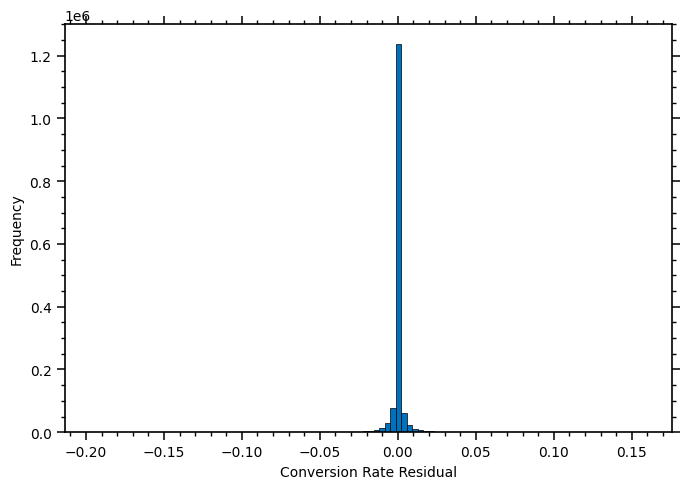

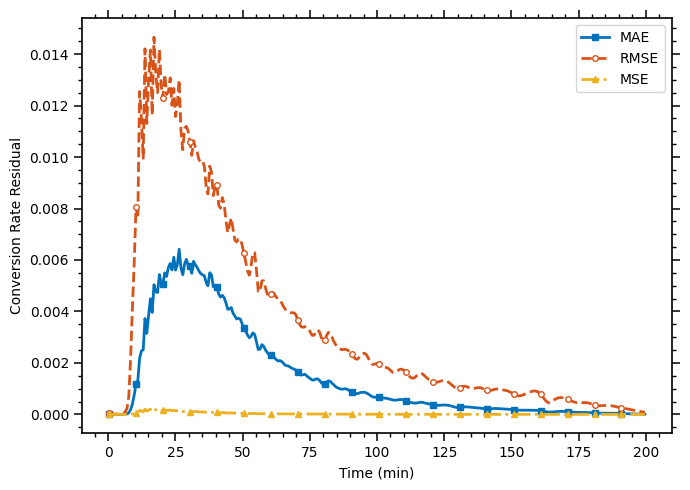

NameError: name 'residual' is not defined

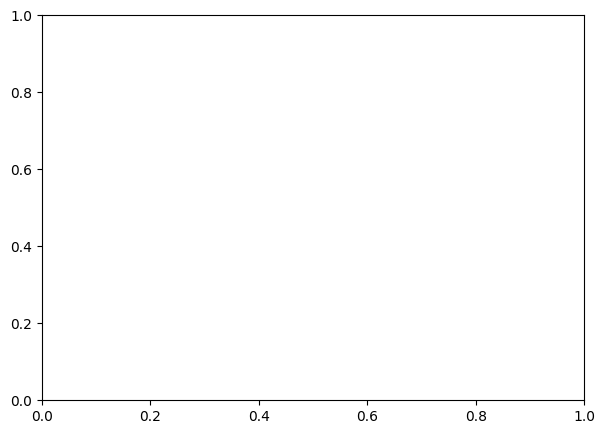

In [ ]:


# CELL 7c: ORIGIN-LIKE Physics Loss / DAEM Residual Error Analysis

# DAEM residual

def daem_residual_numpy(alpha_pred, branch_norm, trunk_norm):
    R = 8.314
    T0 = 273.15

    alpha_pred = np.squeeze(alpha_pred)

    branch_phys = branch_norm * branch_std + branch_mean
    trunk_phys = trunk_norm * trunk_std + trunk_mean

    t = trunk_phys[:, :, 0]
    beta = trunk_phys[:, :, 1]

    logA = branch_phys[:, [0, 3, 6]]
    E = branch_phys[:, [1, 4, 7]] * 1000.0
    c = branch_phys[:, [2, 5, 8]]

    A = 10.0 ** logA

    T = T0 + beta[:, :, None] * t[:, :, None]

    A = A[:, None, :]
    E = E[:, None, :]
    c = c[:, None, :]

    k = A * np.exp(-E / (R * T))

    dt = t[:, 1:] - t[:, :-1]

    k_avg = 0.5 * (k[:, 1:, :] + k[:, :-1, :])
    integ_step = k_avg * dt[:, :, None]
    integ = np.cumsum(integ_step, axis=1)

    zero = np.zeros_like(integ[:, :1, :])
    integ = np.concatenate([zero, integ], axis=1)

    alpha_i = 1.0 - np.exp(-integ)
    alpha_daem = np.sum(c * alpha_i, axis=-1)

    dalpha_dt_pred = (alpha_pred[:, 1:] - alpha_pred[:, :-1]) / (dt + 1e-8)
    dalpha_dt_daem = (alpha_daem[:, 1:] - alpha_daem[:, :-1]) / (dt + 1e-8)

    residual = dalpha_dt_pred - dalpha_dt_daem

    physics_mse_each = np.mean(residual ** 2, axis=1)
    physics_mae_time = np.mean(np.abs(residual), axis=0)
    physics_rmse_time = np.sqrt(np.mean(residual ** 2, axis=0))

    return residual, physics_mse_each, physics_mae_time, physics_rmse_time



# Match prediction size with test metadata

predictions = np.squeeze(predictions)
targets = np.squeeze(targets)

N_eval = predictions.shape[0]

branch_eval = branch_test[:N_eval]
trunk_eval = trunk_test[:N_eval]

print("Predictions shape:", predictions.shape)
print("Branch eval shape:", branch_eval.shape)
print("Trunk eval shape :", trunk_eval.shape)

physics_residuals, physics_mse_each, physics_mae_time, physics_rmse_time = daem_residual_numpy(
    predictions,
    branch_eval,
    trunk_eval
)

physics_loss_mean = np.mean(physics_mse_each)
physics_loss_median = np.median(physics_mse_each)

print("Mean DAEM physics residual MSE  :", physics_loss_mean)
print("Median DAEM physics residual MSE:", physics_loss_median)


# Figure 6: Physics Residual Distribution

fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(
    physics_residuals.flatten(),
    bins=100,
    color="#0072BD",
    edgecolor="black",
    linewidth=0.5,
    alpha=1.0
)

ax.set_xlabel("Conversion Rate Residual")
ax.set_ylabel("Frequency")

origin_axes(ax)

fig.tight_layout()
fig.savefig(
    os.path.join(SAVE_DIR, "Conversion Rate Residual_distribution_origin.png"),
    dpi=600,
    bbox_inches="tight",
    transparent=False,
    facecolor="white"
)
plt.show()

# Figure 7: Physics Residual Error vs Time
# MAE, RMSE, MSE

t_mid = 0.5 * (t_grid[1:] + t_grid[:-1])

physics_mae_time = np.mean(np.abs(physics_residuals), axis=0)
physics_mse_time = np.mean(physics_residuals ** 2, axis=0)
physics_rmse_time = np.sqrt(physics_mse_time)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    t_mid,
    physics_mae_time,
    color="#0072BD",
    lw=2.0,
    marker="s",
    markersize=4,
    markerfacecolor="#0072BD",
    markeredgecolor="#0072BD",
    markevery=15,
    label="MAE"
)

ax.plot(
    t_mid,
    physics_rmse_time,
    color="#D95319",
    lw=2.0,
    ls="--",
    marker="o",
    markersize=4,
    markerfacecolor="white",
    markeredgecolor="#D95319",
    markevery=15,
    label="RMSE"
)

ax.plot(
    t_mid,
    physics_mse_time,
    color="#EDB120",
    lw=2.0,
    ls="-.",
    marker="^",
    markersize=4,
    markerfacecolor="#EDB120",
    markeredgecolor="#EDB120",
    markevery=15,
    label="MSE"
)

ax.set_xlabel("Time (min)")
ax.set_ylabel("Conversion Rate Residual")

origin_axes(ax)
ax.legend(loc="best")

fig.tight_layout()
fig.savefig(
    os.path.join(SAVE_DIR, "physics_residual_mae_rmse_mse_vs_time_origin.png"),
    dpi=600,
    bbox_inches="tight",
    transparent=False,
    facecolor="white"
)
plt.show()


# Figure 8: Physics Loss Per Test Sample

fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(
    residual,
    bins=100,
    color="#EDB120",
    edgecolor="black",
    linewidth=0.5,
    alpha=1.0
)

ax.set_xlabel("Physics Loss ")
ax.set_ylabel("Frequency")

origin_axes(ax)

fig.tight_layout()
fig.savefig(
    os.path.join(SAVE_DIR, "physics_loss_per_sample_origin.png"),
    dpi=600,
    bbox_inches="tight",
    transparent=False,
    facecolor="white"
)
plt.show()

print("Origin-like physics residual figures saved to:", SAVE_DIR)

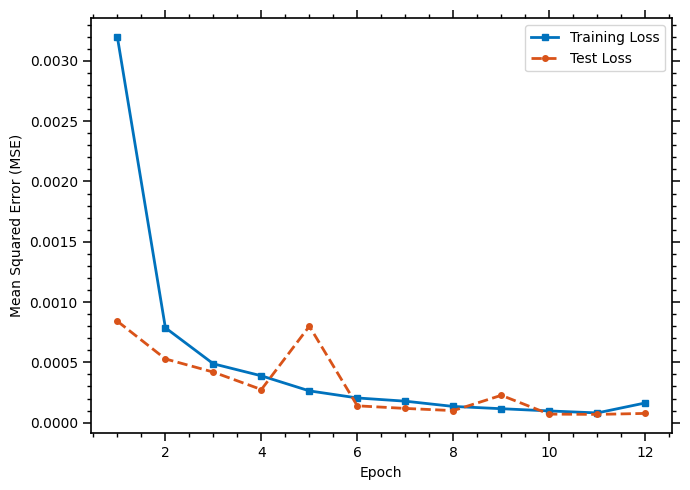

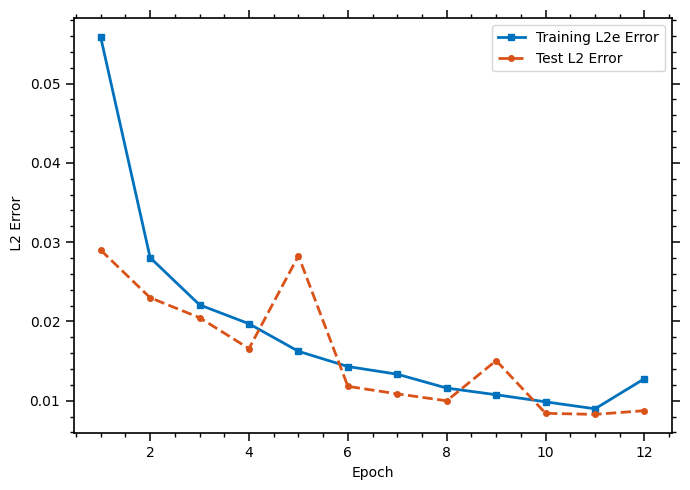

In [ ]:

# L2 RELATIVE ERROR LEARNING CURVE




train_l2_like = np.sqrt(np.array(train_data_losses))
val_l2_like = np.sqrt(np.array(val_data_losses))


# Plot 1: MSE Learning Curve

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    epochs,
    train_losses,
    color="#0072BD",
    lw=2,
    marker="s",
    markersize=4,
    markevery=max(1, len(epochs)//10),
    label="Training"
)

ax.plot(
    epochs,
    val_losses,
    color="#D95319",
    lw=2,
    ls="--",
    marker="o",
    markersize=4,
    markevery=max(1, len(epochs)//10),
    label="Test"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")

origin_axes(ax)
ax.legend(loc="best")

fig.tight_layout()
fig.savefig(
    os.path.join(SAVE_DIR, "learning_curve_mse_origin.png"),
    dpi=600,
    bbox_inches="tight",
    transparent=False,
    facecolor="white"
)
plt.show()

# Plot 2: L2 Error Learning Curve

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    epochs,
    train_l2_like,
    color="#0072BD",
    lw=2,
    marker="s",
    markersize=4,
    markevery=max(1, len(epochs)//10),
    label="Training "
)

ax.plot(
    epochs,
    val_l2_like,
    color="#D95319",
    lw=2,
    ls="--",
    marker="o",
    markersize=4,
    markevery=max(1, len(epochs)//10),
    label="Test "
)

ax.set_xlabel("Epoch")
ax.set_ylabel("L² Loss")

origin_axes(ax)
ax.legend(loc="best")

fig.tight_layout()
fig.savefig(
    os.path.join(SAVE_DIR, "learning_curve_l2_origin.png"),
    dpi=600,
    bbox_inches="tight",
    transparent=False,
    facecolor="white"
)
plt.show()

In [ ]:
# ============================================================
# FREEZE FORWARD MODEL (Standalone)
# Loads trained model, freezes it, saves for inverse network


# 2. Define SAVE_DIR

SAVE_DIR = "/content/drive/MyDrive/PI_DeepONet_Checkpoints"
CHECKPOINT = os.path.join(SAVE_DIR, "ForwardDeepONet_PI.pt")
FROZEN_PATH = os.path.join(SAVE_DIR, "ForwardDeepONet_PI_Frozen.pt")


# 4. Define Model Architecture (must match trained model)
class ForwardDeepONet(nn.Module):
    def __init__(self, branch_dim=9, trunk_dim=2, hidden=256, basis_dim=128):
        super().__init__()
        self.branch = nn.Sequential(
            nn.Linear(branch_dim, hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, basis_dim)
        )
        self.trunk = nn.Sequential(
            nn.Linear(trunk_dim, hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, basis_dim)
        )
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, branch, trunk):
        b = self.branch(branch)
        batch_size, n_points, _ = trunk.shape
        trunk_flat = trunk.reshape(-1, 2)
        t = self.trunk(trunk_flat)
        t = t.reshape(batch_size, n_points, -1)
        y = torch.einsum('bi,bni->bn', b, t)
        y = y.unsqueeze(-1)
        return torch.sigmoid(y + self.bias)

# ------------------------------------------------------------
# 5. Load Trained Model
print("\nLoading trained model...")
if not os.path.exists(CHECKPOINT):
    print(f"❌ Checkpoint not found: {CHECKPOINT}")
    print("   Please train the model first.")
    model = None
else:
    checkpoint = torch.load(CHECKPOINT, map_location=device)

    model = ForwardDeepONet().to(device)
    model.load_state_dict(checkpoint["model"])
    model.eval()

    print(f"✅ Model loaded from epoch {checkpoint.get('epoch', 'unknown')}")
    if 'best_val_loss' in checkpoint:
        print(f"   Best validation loss: {checkpoint['best_val_loss']:.6e}")
    print(f"   Model has {sum(p.numel() for p in model.parameters()):,} parameters")

# ------------------------------------------------------------
# 6. Freeze All Parameters
if model is not None:
    print("\nFreezing model parameters...")

    # Count trainable before freezing
    trainable_before = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"   Trainable before freeze: {trainable_before:,}")

    # Freeze all parameters
    for param in model.parameters():
        param.requires_grad = False

    # Verify freezing
    trainable_after = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"   Trainable after freeze: {trainable_after:,} ✓")

    if trainable_after == 0:
        print("   ✅ All parameters frozen successfully!")
    else:
        print(f"   ⚠️ Warning: {trainable_after} parameters still trainable!")

    # ------------------------------------------------------------
    # 7. Save Frozen Model (Full checkpoint with metadata)
    print("\nSaving frozen model...")

    # Save both state_dict and metadata
    torch.save({
        'model_state_dict': model.state_dict(),
        'model_class': 'ForwardDeepONet',
        'branch_dim': 9,
        'trunk_dim': 2,
        'hidden': 256,
        'basis_dim': 128,
        'total_params': total_params,
        'frozen': True,
        'device': str(device)
    }, FROZEN_PATH)

    print(f"✅ Frozen model saved to: {FROZEN_PATH}")
    print(f"   File size: {os.path.getsize(FROZEN_PATH) / 1024 / 1024:.2f} MB")

    # ------------------------------------------------------------
    # 8. Test Load Frozen Model
    print("\nTesting frozen model load...")

    # Load with metadata
    frozen_data = torch.load(FROZEN_PATH, map_location=device)
    test_model = ForwardDeepONet().to(device)
    test_model.load_state_dict(frozen_data['model_state_dict'])
    test_model.eval()

    # Verify all parameters are frozen
    for param in test_model.parameters():
        param.requires_grad = False

    # Test inference
    print("   Testing inference...")
    test_branch = torch.randn(2, 9, device=device)
    test_trunk = torch.randn(2, 300, 2, device=device)
    with torch.no_grad():
        test_output = test_model(test_branch, test_trunk)
    print(f"   ✅ Inference successful! Output shape: {test_output.shape}")

    print("\n" + "="*60)
    print("✅ FREEZE COMPLETE")
    print("="*60)
    print(f"Frozen model path: {FROZEN_PATH}")
    print(f"Total parameters frozen: {total_params:,}")
    print("Use this model for inverse network without running training cells.")
else:
    print("\n❌ Freeze failed: Model not loaded.")

Device: cuda

Loading trained model...
✅ Model loaded from epoch 9
   Best validation loss: 6.841266e-05
   Model has 332,289 parameters

Freezing model parameters...
   Trainable before freeze: 332,289
   Trainable after freeze: 0 ✓
   ✅ All parameters frozen successfully!

Saving frozen model...
✅ Frozen model saved to: /content/drive/MyDrive/PI_DeepONet_Checkpoints/ForwardDeepONet_PI_Frozen.pt
   File size: 1.27 MB

Testing frozen model load...
   Testing inference...
   ✅ Inference successful! Output shape: torch.Size([2, 300, 1])

✅ FREEZE COMPLETE
Frozen model path: /content/drive/MyDrive/PI_DeepONet_Checkpoints/ForwardDeepONet_PI_Frozen.pt
Total parameters frozen: 332,289
Use this model for inverse network without running training cells.


DEVICE INFORMATION
Device : cuda
GPU    : NVIDIA A100-SXM4-80GB
CUDA   : 12.8
Memory : 79.25 GB

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LOADING DATASET
Branch : (6727680, 9)
Trunk  : (6727680, 300, 2)
Alpha  : (6727680, 300)

Training : 5382144
Testing  : 1345536

MOVING DATA TO GPU
GPU Memory Used : 22.85 GB

NORMALIZING PARAMETERS
Normalization complete.

DATA SUMMARY
Batch Size : 8192
Train Batches : 657
Test Batches  : 165

Branch Mean
[ 13.534126   269.36734      0.33329076  13.53492    269.367
   0.33340412  13.534685   269.35577      0.3333051 ]

Branch Std
[ 2.3876426  61.349503    0.20874608  2.387331   61.343754    0.20877011
  2.3875144  61.348835    0.20878166]

GPU Memory Used : 23.07 GB
CELL 1 COMPLETE


In [ ]:

# Inverse_CELL 1
# Inverse Model Setup: Load Data Without Leakage


DATA_PATH = "/content/drive/MyDrive/Forward_PI_DeepONet/forward_dataset_canonical.npz"
FROZEN_FORWARD_PATH = os.path.join(SAVE_DIR, "ForwardDeepONet_PI_Frozen.pt")
INVERSE_SAVE_PATH = os.path.join(SAVE_DIR, "InverseNet_Best.pt")



SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision("high")

# ------------------------------------------------------------
# Load original saved forward dataset
# ------------------------------------------------------------
data = np.load(DATA_PATH)

branch_all = data["branch"].astype(np.float32)   # (N, 9), physical branch
trunk_all  = data["trunk"].astype(np.float32)    # (N, 300, 2), physical t,beta
alpha_all  = data["alpha"].astype(np.float32)    # (N, 300)
t_grid     = data["t"].astype(np.float32)

print("branch_all:", branch_all.shape)
print("trunk_all :", trunk_all.shape)
print("alpha_all :", alpha_all.shape)


# Leakage-safe grouped split
# Same kinetic branch/reaction must not appear in both sets.
branch_key = np.ascontiguousarray(branch_all).view(
    np.dtype((np.void, branch_all.dtype.itemsize * branch_all.shape[1]))
).reshape(-1)

unique_keys, group_ids = np.unique(branch_key, return_inverse=True)
unique_group_ids = np.arange(len(unique_keys))

train_groups, test_groups = train_test_split(
    unique_group_ids,
    test_size=0.10,
    random_state=SEED,
    shuffle=True
)

train_mask = np.isin(group_ids, train_groups)
test_mask  = np.isin(group_ids, test_groups)

branch_train_phys = branch_all[train_mask]
trunk_train_phys  = trunk_all[train_mask]
alpha_train       = alpha_all[train_mask]

branch_test_phys = branch_all[test_mask]
trunk_test_phys  = trunk_all[test_mask]
alpha_test       = alpha_all[test_mask]

print("Unique reactions total:", len(unique_group_ids))
print("Unique train reactions:", len(train_groups))
print("Unique test reactions :", len(test_groups))
print("Train curves:", len(branch_train_phys))
print("Test curves :", len(branch_test_phys))


# Normalization from train only-
# Use the same normalization stats used to train the frozen forward model
branch_mean = np.load(os.path.join(SAVE_DIR, "branch_mean.npy"))
branch_std  = np.load(os.path.join(SAVE_DIR, "branch_std.npy"))

trunk_mean = np.load(os.path.join(SAVE_DIR, "trunk_mean.npy"))
trunk_std  = np.load(os.path.join(SAVE_DIR, "trunk_std.npy"))

branch_train_norm = (branch_train_phys - branch_mean) / branch_std
branch_test_norm  = (branch_test_phys - branch_mean) / branch_std

trunk_train_norm = (trunk_train_phys - trunk_mean) / trunk_std
trunk_test_norm  = (trunk_test_phys - trunk_mean) / trunk_std

# Save inverse split stats
np.save(os.path.join(SAVE_DIR, "inverse_branch_mean.npy"), branch_mean)
np.save(os.path.join(SAVE_DIR, "inverse_branch_std.npy"), branch_std)
np.save(os.path.join(SAVE_DIR, "inverse_trunk_mean.npy"), trunk_mean)
np.save(os.path.join(SAVE_DIR, "inverse_trunk_std.npy"), trunk_std)

print("Inverse normalization statistics saved.")

Device: cuda
branch_all: (1121280, 9)
trunk_all : (1121280, 300, 2)
alpha_all : (1121280, 300)
Unique reactions total: 90720
Unique train reactions: 81648
Unique test reactions : 9072
Train curves: 1009224
Test curves : 112056
Inverse normalization statistics saved.


In [ ]:

# Inverse_CELL 2
# Forward DeepONet Architecture + Load Frozen Model
class ForwardDeepONet(nn.Module):

    def __init__(self, branch_dim=9, trunk_dim=2, hidden=256, basis_dim=128):
        super().__init__()

        self.branch = nn.Sequential(
            nn.Linear(branch_dim, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, basis_dim)
        )

        self.trunk = nn.Sequential(
            nn.Linear(trunk_dim, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, basis_dim)
        )

        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, branch, trunk):
        b = self.branch(branch)

        batch_size, n_points, _ = trunk.shape
        trunk_flat = trunk.reshape(-1, 2)

        t = self.trunk(trunk_flat)
        t = t.reshape(batch_size, n_points, -1)

        y = torch.einsum("bi,bni->bn", b, t)
        y = y.unsqueeze(-1)

        return torch.sigmoid(y + self.bias)


frozen_data = torch.load(FROZEN_FORWARD_PATH, map_location=device)

forward_model = ForwardDeepONet(
    branch_dim=frozen_data.get("branch_dim", 9),
    trunk_dim=frozen_data.get("trunk_dim", 2),
    hidden=frozen_data.get("hidden", 256),
    basis_dim=frozen_data.get("basis_dim", 128),
).to(device)

forward_model.load_state_dict(frozen_data["model_state_dict"])
forward_model.eval()

for p in forward_model.parameters():
    p.requires_grad = False

print("Frozen forward DeepONet loaded.")
print("Trainable forward params:", sum(p.numel() for p in forward_model.parameters() if p.requires_grad))

Frozen forward DeepONet loaded.
Trainable forward params: 0


In [ ]:

# CELL 3
# Inverse Dataset and Fast DataLoaders
# Precompute trunk basis only for unique beta value

# Get beta IDs from normalized trunk
def build_beta_ids(trunk_norm):
    """
    trunk_norm: (N, Ntime, 2), normalized trunk
    beta is constant along time, so use first time point.
    """
    beta_values = trunk_norm[:, 0, 1]
    unique_beta, beta_ids = np.unique(beta_values, return_inverse=True)

    return unique_beta.astype(np.float32), beta_ids.astype(np.int64)


unique_beta_train, beta_id_train = build_beta_ids(trunk_train_norm)
unique_beta_test, beta_id_test = build_beta_ids(trunk_test_norm)

print("Unique train beta:", len(unique_beta_train))
print("Unique test beta :", len(unique_beta_test))


# ------------------------------------------------------------
# Precompute trunk basis for each unique beta/trunk curve
@torch.no_grad()
def compute_unique_trunk_basis(trunk_norm, unique_beta):
    """
    Computes forward_model.trunk only once per unique beta.
    Returns tensor shape: (N_unique_beta, Ntime, basis_dim)
    """

    forward_model.eval()

    basis_list = []

    beta_values = trunk_norm[:, 0, 1]

    for beta in unique_beta:
        idx = np.where(beta_values == beta)[0][0]

        trunk_one = torch.from_numpy(
            trunk_norm[idx:idx+1]
        ).float().to(device)

        B, N, _ = trunk_one.shape

        trunk_flat = trunk_one.reshape(-1, 2)

        basis_flat = forward_model.trunk(trunk_flat)

        basis = basis_flat.reshape(B, N, -1).squeeze(0)

        basis_list.append(basis.cpu())

    trunk_basis_unique = torch.stack(basis_list, dim=0).float()

    return trunk_basis_unique


print("Precomputing unique train trunk basis...")
trunk_basis_train_unique = compute_unique_trunk_basis(
    trunk_train_norm,
    unique_beta_train
)

print("Precomputing unique test trunk basis...")
trunk_basis_test_unique = compute_unique_trunk_basis(
    trunk_test_norm,
    unique_beta_test
)

print("trunk_basis_train_unique:", trunk_basis_train_unique.shape)
print("trunk_basis_test_unique :", trunk_basis_test_unique.shape)


# Dataset
class InverseDataset(Dataset):

    def __init__(
        self,
        trunk_norm,
        beta_ids,
        alpha,
        branch_norm,
        branch_phys
    ):
        self.trunk_norm = torch.from_numpy(trunk_norm).float()
        self.beta_ids = torch.from_numpy(beta_ids).long()
        self.alpha = torch.from_numpy(alpha).float()
        self.branch_norm = torch.from_numpy(branch_norm).float()
        self.branch_phys = torch.from_numpy(branch_phys).float()

    def __len__(self):
        return self.alpha.shape[0]

    def __getitem__(self, idx):
        return (
            self.trunk_norm[idx],
            self.beta_ids[idx],
            self.alpha[idx],
            self.branch_norm[idx],
            self.branch_phys[idx],
        )

train_dataset = InverseDataset(
    trunk_train_norm,
    beta_id_train,
    alpha_train,
    branch_train_norm,
    branch_train_phys
)

test_dataset = InverseDataset(
    trunk_test_norm,
    beta_id_test,
    alpha_test,
    branch_test_norm,
    branch_test_phys
)

BATCH_SIZE = 2048
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False,
    drop_last=False
)

# Move unique trunk bases to GPU once
trunk_basis_train_unique = trunk_basis_train_unique.to(device)
trunk_basis_test_unique = trunk_basis_test_unique.to(device)

print("Train batches:", len(train_loader))
print("Test batches :", len(test_loader))
print("Unique trunk basis ready on:", trunk_basis_train_unique.device)

Unique train beta: 14
Unique test beta : 14
Precomputing unique train trunk basis...
Precomputing unique test trunk basis...
trunk_basis_train_unique: torch.Size([14, 300, 128])
trunk_basis_test_unique : torch.Size([14, 300, 128])
Train batches: 493
Test batches : 55
Unique trunk basis ready on: cuda:0


In [ ]:

# CELL 4
# Physics-Constrained Inverse Network
# Input : normalized trunk(t,beta), alpha(t)
# Output: physical branch + normalized branch
class ResidualConvBlock(nn.Module):
    def __init__(self, channels, kernel_size=5, dilation=1, dropout=0.05):
        super().__init__()

        padding = dilation * (kernel_size - 1) // 2

        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=padding, dilation=dilation),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(channels, channels, kernel_size, padding=padding, dilation=dilation),
            nn.BatchNorm1d(channels),
        )

        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.block(x))


class TemporalSelfAttention(nn.Module):
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.norm = nn.LayerNorm(channels)
        self.attn = nn.MultiheadAttention(
            embed_dim=channels,
            num_heads=num_heads,
            batch_first=True
        )

    def forward(self, x):
        # x: [B, C, T] -> [B, T, C]
        x_t = x.transpose(1, 2)
        x_n = self.norm(x_t)
        attn_out, _ = self.attn(x_n, x_n, x_n, need_weights=False)
        x_t = x_t + attn_out
        return x_t.transpose(1, 2)


class InverseNet(nn.Module):

    def __init__(
        self,
        branch_mean,
        branch_std,
        n_time=300,
        hidden=512,
        branch_dim=9
    ):
        super().__init__()

        self.register_buffer("branch_mean", torch.tensor(branch_mean, dtype=torch.float32))
        self.register_buffer("branch_std", torch.tensor(branch_std, dtype=torch.float32))

        self.register_buffer("logA_min", torch.tensor(10.0))
        self.register_buffer("logA_max", torch.tensor(17.0))

        self.register_buffer("E_min", torch.tensor(180.0))
        self.register_buffer("E_max", torch.tensor(380.0))

        channels = 256
        pool_size = 8

        self.stem = nn.Sequential(
            nn.Conv1d(3, channels, kernel_size=9, padding=4),
            nn.BatchNorm1d(channels),
            nn.GELU(),
        )

        self.res_blocks = nn.Sequential(
            ResidualConvBlock(channels, kernel_size=7, dilation=1),
            ResidualConvBlock(channels, kernel_size=5, dilation=2),
            ResidualConvBlock(channels, kernel_size=5, dilation=4),
        )

        self.attn = TemporalSelfAttention(channels, num_heads=4)

        self.avg_pool = nn.AdaptiveAvgPool1d(pool_size)
        self.max_pool = nn.AdaptiveMaxPool1d(pool_size)

        feat_dim = channels * pool_size * 2

        self.shared_fc = nn.Sequential(
            nn.Linear(feat_dim, hidden),
            nn.GELU(),
            nn.Dropout(0.05),
            nn.Linear(hidden, hidden),
            nn.GELU(),
        )

        self.head_logA = nn.Linear(hidden, 3)
        self.head_E = nn.Linear(hidden, 3)
        self.head_c = nn.Linear(hidden, 3)

    def forward(self, trunk_norm, alpha):
        alpha_channel = alpha.unsqueeze(-1)

        x = torch.cat([trunk_norm, alpha_channel], dim=-1)
        x = x.permute(0, 2, 1)

        x = self.stem(x)
        x = self.res_blocks(x)
        x = self.attn(x)

        z_avg = self.avg_pool(x).flatten(1)
        z_max = self.max_pool(x).flatten(1)
        z = torch.cat([z_avg, z_max], dim=1)

        z = self.shared_fc(z)

        raw_logA = self.head_logA(z)
        raw_E = self.head_E(z)
        raw_c = self.head_c(z)

        logA = self.logA_min + (self.logA_max - self.logA_min) * torch.sigmoid(raw_logA)
        E = self.E_min + (self.E_max - self.E_min) * torch.sigmoid(raw_E)
        c = torch.softmax(raw_c, dim=1)

        branch_phys = torch.zeros(
            alpha.shape[0],
            9,
            dtype=alpha.dtype,
            device=alpha.device
        )

        branch_phys[:, [0, 3, 6]] = logA
        branch_phys[:, [1, 4, 7]] = E
        branch_phys[:, [2, 5, 8]] = c

        branch_norm = (branch_phys - self.branch_mean) / self.branch_std

        return branch_norm, branch_phys
inverse_model = InverseNet(
    branch_mean=branch_mean,
    branch_std=branch_std,
    n_time=alpha_train.shape[1]
).to(device)

try:
    inverse_model = torch.compile(inverse_model)
    print("torch.compile enabled.")
except Exception as e:
    print("torch.compile skipped:", e)

print("Inverse trainable params:", sum(p.numel() for p in inverse_model.parameters() if p.requires_grad))

torch.compile enabled.
Inverse trainable params: 4869129


In [ ]:

# CELL 5
# Loss Functions
# Physics-informed loss = frozen forward reconstruction
mse = nn.MSELoss()

def monotonicity_loss(alpha_pred):
    diff = alpha_pred[:, 1:] - alpha_pred[:, :-1]
    return torch.relu(-diff).mean()

def c_sum_loss(branch_phys):
    c = branch_phys[:, [2, 5, 8]]
    return ((c.sum(dim=1) - 1.0) ** 2).mean()

def total_inverse_loss(
    branch_pred_norm,
    branch_pred_phys,
    branch_true_norm,
    alpha_recon,
    alpha_true,
    lambda_recon=1.0,
    lambda_branch=0.2,
    lambda_mono=0.01,
    lambda_c=0.01
):
    loss_recon = mse(alpha_recon, alpha_true)
    loss_branch = mse(branch_pred_norm, branch_true_norm)
    loss_mono = monotonicity_loss(alpha_recon)
    loss_c = c_sum_loss(branch_pred_phys)

    loss = (
        lambda_recon * loss_recon
        + lambda_branch * loss_branch
        + lambda_mono * loss_mono
        + lambda_c * loss_c
    )

    return loss, loss_recon, loss_branch, loss_mono, loss_c

In [ ]:

# CELL 6A
# Ensemble + Curriculum Configuration
N_ENSEMBLE = 1          # use 5 first; increase to 10 if time allows
EPOCHS = 100
BASE_SEED = 1

ENSEMBLE_DIR = os.path.join(SAVE_DIR, "inverse_ensemble")
os.makedirs(ENSEMBLE_DIR, exist_ok=True)

def set_all_seeds(seed):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

def curriculum_weights(epoch, total_epochs):
    progress = epoch / total_epochs

    if progress < 0.70:
        lambda_branch = 1.0
        lambda_recon = 0.25
        lambda_mono = 0.005
        lambda_c = 0.01

    elif progress < 0.90:
        lambda_branch = 0.75
        lambda_recon = 0.50
        lambda_mono = 0.01
        lambda_c = 0.01

    else:
        lambda_branch = 0.50
        lambda_recon = 0.75
        lambda_mono = 0.02
        lambda_c = 0.01

    return lambda_recon, lambda_branch, lambda_mono, lambda_c


ensemble_seeds = [BASE_SEED + i * 100 for i in range(N_ENSEMBLE)]
print("Fixed ensemble seeds:", ensemble_seeds)

Fixed ensemble seeds: [1]


In [ ]:

# CELL 6B
# Train Fixed-Seed Ensemble with Curriculum Learning + Resume
# Fast validation: partial every epoch, full every 10 epochs
all_histories = []
ensemble_best_paths = []

# VAL_MAX_BATCHES = 10
# FULL_VAL_EVERY = 10

for model_id, seed in enumerate(ensemble_seeds, start=1):

    print("\n" + "=" * 70)
    print(f"Training ensemble model {model_id}/{N_ENSEMBLE} | seed={seed}")
    print("=" * 70)

    set_all_seeds(seed)

    best_path = os.path.join(
        ENSEMBLE_DIR,
        f"InverseNet_ensemble_{model_id:02d}_seed_{seed}_BEST.pt"
    )

    last_path = os.path.join(
        ENSEMBLE_DIR,
        f"InverseNet_ensemble_{model_id:02d}_seed_{seed}_LAST.pt"
    )

    inverse_model = InverseNet(
        branch_mean=branch_mean,
        branch_std=branch_std,
        n_time=alpha_train.shape[1]
    ).to(device)

    try:
        inverse_model = torch.compile(inverse_model)
        print("torch.compile enabled.")
    except Exception as e:
        print("torch.compile skipped:", e)

    optimizer = torch.optim.AdamW(
        inverse_model.parameters(),
        lr=1e-3,
        weight_decay=1e-5
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS,
        eta_min=1e-5
    )

    scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

    best_test_loss = float("inf")
    start_epoch = 1

    history = {
        "train_total": [],
        "test_total": [],
        "test_recon": [],
        "test_branch": [],
        "test_mono": [],
        "test_c": [],
        "lambda_recon": [],
        "lambda_branch": [],
        "lambda_mono": [],
        "lambda_c": [],
        "validation_mode": [],
    }

    if os.path.exists(last_path):
        ckpt = torch.load(last_path, map_location=device, weights_only=False)

        model_to_load = (
            inverse_model._orig_mod
            if hasattr(inverse_model, "_orig_mod")
            else inverse_model
        )

        model_to_load.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])

        if "scaler_state_dict" in ckpt:
            scaler.load_state_dict(ckpt["scaler_state_dict"])

        start_epoch = ckpt["epoch"] + 1
        best_test_loss = ckpt["best_test_loss"]
        history = ckpt["history"]

        if "validation_mode" not in history:
            history["validation_mode"] = []

        print(f"Resuming from epoch {start_epoch}")
        print(f"Best previous test loss: {best_test_loss:.6e}")

    else:
        print("Training from scratch.")

    for epoch in range(start_epoch, EPOCHS + 1):

        lambda_recon, lambda_branch, lambda_mono, lambda_c = curriculum_weights(
            epoch,
            EPOCHS
        )

        inverse_model.train()
        train_total = 0.0

        for trunk_norm, beta_ids, alpha_true, branch_true_norm, branch_true_phys in train_loader:

            trunk_norm = trunk_norm.to(device, non_blocking=True)
            beta_ids = beta_ids.to(device, non_blocking=True)
            alpha_true = alpha_true.to(device, non_blocking=True)
            branch_true_norm = branch_true_norm.to(device, non_blocking=True)

            trunk_basis = trunk_basis_train_unique[beta_ids]

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                branch_pred_norm, branch_pred_phys = inverse_model(
                    trunk_norm,
                    alpha_true
                )

                branch_basis = forward_model.branch(branch_pred_norm)

                alpha_recon = torch.einsum(
                    "bi,bni->bn",
                    branch_basis,
                    trunk_basis
                )

                alpha_recon = torch.sigmoid(alpha_recon + forward_model.bias)

                loss, loss_recon, loss_branch, loss_mono, loss_c = total_inverse_loss(
                    branch_pred_norm,
                    branch_pred_phys,
                    branch_true_norm,
                    alpha_recon,
                    alpha_true,
                    lambda_recon=lambda_recon,
                    lambda_branch=lambda_branch,
                    lambda_mono=lambda_mono,
                    lambda_c=lambda_c
                )

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(inverse_model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            train_total += loss.item()

        avg_train_total = train_total / len(train_loader)


        # Fast Validation

        inverse_model.eval()

        test_total = 0.0
        test_recon = 0.0
        test_branch = 0.0
        test_mono = 0.0
        test_c = 0.0
        val_batches_used = 0

        validation_mode = "full"
        max_val_batches = None


        with torch.no_grad():

            for val_batch_idx, (
                trunk_norm,
                beta_ids,
                alpha_true,
                branch_true_norm,
                branch_true_phys
            ) in enumerate(test_loader):

                if max_val_batches is not None and val_batch_idx >= max_val_batches:
                    break

                trunk_norm = trunk_norm.to(device, non_blocking=True)
                beta_ids = beta_ids.to(device, non_blocking=True)
                alpha_true = alpha_true.to(device, non_blocking=True)
                branch_true_norm = branch_true_norm.to(device, non_blocking=True)

                # IMPORTANT: use test unique trunk basis for test_loader
                trunk_basis = trunk_basis_test_unique[beta_ids]

                with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                    branch_pred_norm, branch_pred_phys = inverse_model(
                        trunk_norm,
                        alpha_true
                    )

                    branch_basis = forward_model.branch(branch_pred_norm)

                    alpha_recon = torch.einsum(
                        "bi,bni->bn",
                        branch_basis,
                        trunk_basis
                    )

                    alpha_recon = torch.sigmoid(alpha_recon + forward_model.bias)

                    loss, loss_recon, loss_branch, loss_mono, loss_c = total_inverse_loss(
                        branch_pred_norm,
                        branch_pred_phys,
                        branch_true_norm,
                        alpha_recon,
                        alpha_true,
                        lambda_recon=lambda_recon,
                        lambda_branch=lambda_branch,
                        lambda_mono=lambda_mono,
                        lambda_c=lambda_c
                    )

                test_total += loss.item()
                test_recon += loss_recon.item()
                test_branch += loss_branch.item()
                test_mono += loss_mono.item()
                test_c += loss_c.item()
                val_batches_used += 1

        avg_test_total = test_total / val_batches_used
        avg_test_recon = test_recon / val_batches_used
        avg_test_branch = test_branch / val_batches_used
        avg_test_mono = test_mono / val_batches_used
        avg_test_c = test_c / val_batches_used

        scheduler.step()

        history["train_total"].append(avg_train_total)
        history["test_total"].append(avg_test_total)
        history["test_recon"].append(avg_test_recon)
        history["test_branch"].append(avg_test_branch)
        history["test_mono"].append(avg_test_mono)
        history["test_c"].append(avg_test_c)
        history["lambda_recon"].append(lambda_recon)
        history["lambda_branch"].append(lambda_branch)
        history["lambda_mono"].append(lambda_mono)
        history["lambda_c"].append(lambda_c)
        history["validation_mode"].append(validation_mode)

        model_to_save = (
            inverse_model._orig_mod
            if hasattr(inverse_model, "_orig_mod")
            else inverse_model
        )

        save_dict = {
            "model_state_dict": model_to_save.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "model_id": model_id,
            "seed": seed,
            "epoch": epoch,
            "best_test_loss": best_test_loss,
            "branch_mean": branch_mean,
            "branch_std": branch_std,
            "trunk_mean": trunk_mean,
            "trunk_std": trunk_std,
            "history": history,
            "epochs_total": EPOCHS,
            "validation_mode": validation_mode,
            "val_batches_used": val_batches_used,
            "curriculum": "branch_to_reconstruction_physics",
            "split": "grouped_by_unique_branch_no_inverse_leakage",
        }

        torch.save(save_dict, last_path)

        if avg_test_total < best_test_loss:
            best_test_loss = avg_test_total
            save_dict["best_test_loss"] = best_test_loss
            torch.save(save_dict, best_path)
            print("Best inverse model saved.")

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"Model {model_id:02d} | "
                f"Epoch {epoch:04d}/{EPOCHS} | "
                f"Train {avg_train_total:.4e} | "
                f"Test {avg_test_total:.4e} ({validation_mode}, {val_batches_used} batches) | "
                f"Recon {avg_test_recon:.4e} | "
                f"Branch {avg_test_branch:.4e} | "
                f"lambda_r {lambda_recon:.2f} | "
                f"lambda_b {lambda_branch:.2f}"
            )

    all_histories.append(history)
    ensemble_best_paths.append(best_path)

    print(f"Best model {model_id} saved:", best_path)
    print(f"Last checkpoint saved:", last_path)
    print(f"Best test loss model {model_id}: {best_test_loss:.6e}")

print("\nAll ensemble models trained.")
print("Saved best paths:")
for p in ensemble_best_paths:
    print(p)


Training ensemble model 1/1 | seed=1
torch.compile enabled.
Resuming from epoch 41
Best previous test loss: 9.636951e-03


W0729 11:57:51.202000 6975 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:7836: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:7836: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:7836: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(


Best inverse model saved.
Best inverse model saved.
Model 01 | Epoch 0045/100 | Train 7.5848e-03 | Test 8.2315e-03 (full, 55 batches) | Recon 2.4184e-04 | Branch 8.1706e-03 | lambda_r 0.25 | lambda_b 1.00
Best inverse model saved.
Best inverse model saved.
Model 01 | Epoch 0050/100 | Train 6.3229e-03 | Test 1.2580e-02 (full, 55 batches) | Recon 2.5351e-04 | Branch 1.2516e-02 | lambda_r 0.25 | lambda_b 1.00
Best inverse model saved.
Model 01 | Epoch 0055/100 | Train 5.3225e-03 | Test 1.0862e-02 (full, 55 batches) | Recon 2.3651e-04 | Branch 1.0803e-02 | lambda_r 0.25 | lambda_b 1.00
Best inverse model saved.
Model 01 | Epoch 0060/100 | Train 4.6065e-03 | Test 9.1673e-03 (full, 55 batches) | Recon 2.1759e-04 | Branch 9.1124e-03 | lambda_r 0.25 | lambda_b 1.00
Best inverse model saved.
Model 01 | Epoch 0065/100 | Train 3.4633e-03 | Test 6.0385e-03 (full, 55 batches) | Recon 1.9370e-04 | Branch 5.9896e-03 | lambda_r 0.25 | lambda_b 1.00
Best inverse model saved.
Model 01 | Epoch 0070/100 |

In [ ]:
# ============================================================
# HIGH-QUALITY 3D SURFACE PLOT
# Run after alpha_true, alpha_pred, beta_used, t_grid are created
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
# ------------------------------------------------------------
# Fixed seed for reproducible graph sample selection
# ------------------------------------------------------------
import random
import numpy as np
import torch

SEED = 2560

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

rng = np.random.default_rng(SEED)
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 12,
    "axes.linewidth": 1.2,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
    "savefig.dpi": 1200,
})

T_mesh, B_mesh = np.meshgrid(t_grid, beta_used)

fig = plt.figure(figsize=(15, 6.5), facecolor="white")

# ------------------------------------------------------------
# Target
# ------------------------------------------------------------
ax1 = fig.add_subplot(1, 2, 1, projection="3d")

surf1 = ax1.plot_surface(
    T_mesh,
    B_mesh,
    alpha_true,
    cmap=cm.jet,
    linewidth=0,
    antialiased=True,
    shade=True,
    rcount=200,
    ccount=200
)

ax1.set_title("Target conversion")
ax1.set_xlabel("Time (min)", labelpad=10)
ax1.set_ylabel("Heating rate, beta (C/min)", labelpad=10)
ax1.set_zlabel("Conversion alpha", labelpad=8)
ax1.set_zlim(0, 1)
ax1.view_init(elev=28, azim=-135)

ax1.xaxis.pane.set_facecolor((1, 1, 1, 1))
ax1.yaxis.pane.set_facecolor((1, 1, 1, 1))
ax1.zaxis.pane.set_facecolor((1, 1, 1, 1))

ax1.xaxis.pane.set_edgecolor("black")
ax1.yaxis.pane.set_edgecolor("black")
ax1.zaxis.pane.set_edgecolor("black")

cb1 = fig.colorbar(
    surf1,
    ax=ax1,
    shrink=0.70,
    pad=0.08,
    aspect=18
)
cb1.set_label("alpha")

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------
ax2 = fig.add_subplot(1, 2, 2, projection="3d")

surf2 = ax2.plot_surface(
    T_mesh,
    B_mesh,
    alpha_pred,
    cmap=cm.jet,
    linewidth=0,
    antialiased=True,
    shade=True,
    rcount=200,
    ccount=200
)

ax2.set_title("Predicted conversion ")
ax2.set_xlabel("Time (min)", labelpad=10)
ax2.set_ylabel("Heating rate, beta (C/min)", labelpad=10)
ax2.set_zlabel("Conversion alpha", labelpad=8)
ax2.set_zlim(0, 1)
ax2.view_init(elev=28, azim=-135)

ax2.xaxis.pane.set_facecolor((1, 1, 1, 1))
ax2.yaxis.pane.set_facecolor((1, 1, 1, 1))
ax2.zaxis.pane.set_facecolor((1, 1, 1, 1))

ax2.xaxis.pane.set_edgecolor("black")
ax2.yaxis.pane.set_edgecolor("black")
ax2.zaxis.pane.set_edgecolor("black")

cb2 = fig.colorbar(
    surf2,
    ax=ax2,
    shrink=0.70,
    pad=0.08,
    aspect=18
)
cb2.set_label("alpha")

fig.suptitle(
    f"R² = {r2:.4f}, RMSE = {rmse:.3e}",
    fontsize=14,
    y=0.98
)


fig.tight_layout(rect=[0, 0, 1, 0.94])

fig.savefig(
    os.path.join(SAVE_DIR, "hybrid_3d_target_prediction_surface_HQ.png"),
    dpi=1200,
    bbox_inches="tight",
    transparent=False,
    facecolor="white"
)

plt.show()

NameError: name 'beta_used' is not defined

In [ ]:

# CELL: ORIGIN-LIKE Inverse Model Performance Evaluation


start_time = time.time()

def l2_relative_error(y_true, y_pred):
    num = np.linalg.norm((y_pred - y_true).reshape(-1), ord=2)
    den = np.linalg.norm(y_true.reshape(-1), ord=2) + 1e-12
    return num / den


def print_metric_block(name, y_true, y_pred):
    mse = mean_squared_error(y_true.flatten(), y_pred.flatten())
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true.flatten(), y_pred.flatten())
    r2 = r2_score(y_true.flatten(), y_pred.flatten())
    l2 = l2_relative_error(y_true, y_pred)

    print(name)
    print(f"MSE             : {mse:.6e}")
    print(f"RMSE            : {rmse:.6e}")
    print(f"MAE             : {mae:.6e}")
    print(f"R²              : {r2:.6f}")
    print(f"L2 Relative Err : {l2:.6e}")
    print()

    return mse, rmse, mae, r2, l2


# Load best inverse model

# Models already loaded from previous cell

inverse_model.eval()
forward_model.eval()

print("Using already loaded CNN inverse model.")
print("Using already loaded frozen forward DeepONet.")



# Evaluation function
def evaluate_inverse_dataset(dataset, trunk_basis_unique, max_samples=10000, batch_size=4096):
    n_samples = min(max_samples, len(dataset))
    indices = np.random.choice(len(dataset), n_samples, replace=False)

    loader = DataLoader(
        Subset(dataset, indices),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    trunk_basis_device = trunk_basis_unique.to(device)

    all_alpha_true = []
    all_alpha_pred = []
    all_branch_true_norm = []
    all_branch_pred_norm = []
    all_trunk_norm = []
    all_beta_ids = []

    with torch.no_grad():
        for batch in loader:

            trunk_norm, beta_ids, alpha_true_batch, branch_true_norm_batch, branch_true_phys_batch = batch

            trunk_norm = trunk_norm.to(device, non_blocking=True)
            beta_ids = beta_ids.to(device, non_blocking=True)
            alpha_true_batch = alpha_true_batch.to(device, non_blocking=True)
            branch_true_norm_batch = branch_true_norm_batch.to(device, non_blocking=True)

            trunk_basis = trunk_basis_device[beta_ids]

            branch_pred_norm, branch_pred_phys = inverse_model(trunk_norm, alpha_true_batch)

            branch_basis = forward_model.branch(branch_pred_norm)
            alpha_recon = torch.einsum("bi,bni->bn", branch_basis, trunk_basis)
            alpha_recon = torch.sigmoid(alpha_recon + forward_model.bias)

            all_alpha_true.append(alpha_true_batch.cpu().numpy())
            all_alpha_pred.append(alpha_recon.cpu().numpy())
            all_branch_true_norm.append(branch_true_norm_batch.cpu().numpy())
            all_branch_pred_norm.append(branch_pred_norm.cpu().numpy())
            all_trunk_norm.append(trunk_norm.cpu().numpy())
            all_beta_ids.append(beta_ids.cpu().numpy())

    alpha_true_out = np.concatenate(all_alpha_true, axis=0)
    alpha_pred_out = np.concatenate(all_alpha_pred, axis=0)

    branch_true_norm_out = np.concatenate(all_branch_true_norm, axis=0)
    branch_pred_norm_out = np.concatenate(all_branch_pred_norm, axis=0)

    trunk_norm_out = np.concatenate(all_trunk_norm, axis=0)
    beta_ids_out = np.concatenate(all_beta_ids, axis=0)

    branch_true_phys_out = branch_true_norm_out * branch_std + branch_mean
    branch_pred_phys_out = branch_pred_norm_out * branch_std + branch_mean

    trunk_phys_out = trunk_norm_out * trunk_std + trunk_mean
    beta_values_out = np.round(trunk_phys_out[:, :, 1].mean(axis=1), 6)

    return {
        "alpha_true": alpha_true_out,
        "alpha_pred": alpha_pred_out,
        "branch_true_norm": branch_true_norm_out,
        "branch_pred_norm": branch_pred_norm_out,
        "branch_true_phys": branch_true_phys_out,
        "branch_pred_phys": branch_pred_phys_out,
        "trunk_norm": trunk_norm_out,
        "beta_ids": beta_ids_out,
        "beta_values": beta_values_out
    }



# Evaluate datasets

np.random.seed(50)

results = {}

if "train_dataset" in globals() and "trunk_basis_train_unique" in globals():
    print("Evaluating training subset...")
    results["Training"] = evaluate_inverse_dataset(
        train_dataset,
        trunk_basis_train_unique,
        max_samples=10000
    )

print("Evaluating test subset...")
results["Test"] = evaluate_inverse_dataset(
    test_dataset,
    trunk_basis_test_unique,
    max_samples=10000
)




# Metrics

print()
print("=" * 60)
print("INVERSE MODEL PERFORMANCE METRICS")
print("=" * 60)

for split_name, res in results.items():
    print(f"\n{split_name} Alpha Reconstruction:")
    print_metric_block(split_name, res["alpha_true"], res["alpha_pred"])

    print(f"{split_name} Branch Prediction - Normalized:")
    print_metric_block(split_name, res["branch_true_norm"], res["branch_pred_norm"])

component_indices = {
    "logA": [0, 3, 6],
    "E": [1, 4, 7],
    "c": [2, 5, 8],
}

print("Per-parameter normalized metrics on Test:")
test_res = results["Test"]

for comp, idx in component_indices.items():
    y_true = test_res["branch_true_norm"][:, idx]
    y_pred = test_res["branch_pred_norm"][:, idx]

    mse_i = mean_squared_error(y_true.flatten(), y_pred.flatten())
    rmse_i = np.sqrt(mse_i)
    mae_i = mean_absolute_error(y_true.flatten(), y_pred.flatten())
    r2_i = r2_score(y_true.flatten(), y_pred.flatten())
    l2_i = l2_relative_error(y_true, y_pred)

    print(f"{comp}: MSE={mse_i:.6e}, RMSE={rmse_i:.6e}, MAE={mae_i:.6e}, R²={r2_i:.6f}, L2={l2_i:.6e}")



# Figure 1: Training history

if "history" in checkpoint:
    history = checkpoint["history"]

    fig, ax = plt.subplots(figsize=(7, 5))

    if "train_total" in history:
        train_total = np.array(history["train_total"])
        ax.plot(
            np.arange(1, len(train_total) + 1),
            train_total,
            color="#0072BD",
            lw=2,
            marker="s",
            markersize=4,
            markevery=max(1, len(train_total)//10),
            label="Training "
        )

    if "test_total" in history:
        test_total = np.array(history["test_total"])
        ax.plot(
            np.arange(1, len(test_total) + 1),
            test_total,
            color="#D95319",
            lw=2,
            ls="--",
            marker="o",
            markersize=4,
            markevery=max(1, len(test_total)//10),
            label="Test"
        )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Total Loss (log)")
    ax.set_yscale("log")
    origin_axes(ax)
    ax.legend(loc="best")

    fig.tight_layout()
    fig.savefig(
        os.path.join(SAVE_DIR, "inverse_learning_curve_origin.png"),
        dpi=600,
        bbox_inches="tight",
        transparent=False,
        facecolor="white"
    )
    plt.show()


# Figure 3: Alpha parity plots - Training, Test

plot_order = []

if "Training" in results:
    plot_order.append("Training")

plot_order.append("Test")


fig, axes = plt.subplots(
    1,
    len(plot_order),
    figsize=(5.2 * len(plot_order), 5),
    sharex=True,
    sharey=True
)

if len(plot_order) == 1:
    axes = [axes]

for ax, name in zip(axes, plot_order):
    res = results[name]

    y_true = res["alpha_true"]
    y_pred = res["alpha_pred"]

    rmse = np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten()))
    r2 = r2_score(y_true.flatten(), y_pred.flatten())
    l2 = l2_relative_error(y_true, y_pred)

    ax.scatter(
        y_true.flatten(),
        y_pred.flatten(),
        s=5,
        alpha=0.35,
        color="#0072BD",
        edgecolors="none",
        label=name
    )

    ax.plot(
        [0, 1],
        [0, 1],
        color="#D95319",
        lw=2,
        ls="--",
        label="Ideal"
    )

    ax.set_title(f"R²={r2:.4f}")
    ax.set_xlabel("True alpha")
    ax.set_ylabel("Predicted alpha")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    origin_axes(ax)
    ax.legend(loc="best")

fig.tight_layout()
fig.savefig(
    os.path.join(SAVE_DIR, "inverse_alpha_parity_train_test_validation_origin.png"),
    dpi=600,
    bbox_inches="tight",
    transparent=False,
    facecolor="white"
)
plt.show()



# Figure 4: Branch parameter parity plots

branch_true_norm = test_res["branch_true_norm"]
branch_pred_norm = test_res["branch_pred_norm"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for ax, (comp, idx) in zip(axes, component_indices.items()):
    y_true = branch_true_norm[:, idx].flatten()
    y_pred = branch_pred_norm[:, idx].flatten()

    r2 = r2_score(y_true, y_pred)
    l2 = l2_relative_error(y_true, y_pred)

    ax.scatter(
        y_true,
        y_pred,
        s=8,
        alpha=0.40,
        color="#0072BD",
        edgecolors="none"
    )

    ax.plot(
        [-3, 3],
        [-3, 3],
        color="#D95319",
        lw=2,
        ls="--"
    )

    ax.set_title(f"{comp}\nR²={r2:.4f}")
    ax.set_xlabel("True normalized")
    ax.set_ylabel("Predicted normalized")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)

    origin_axes(ax)

fig.tight_layout()
fig.savefig(
    os.path.join(SAVE_DIR, "inverse_branch_parameter_parity_origin.png"),
    dpi=600,
    bbox_inches="tight",
    transparent=False,
    facecolor="white"
)
plt.show()



# Reconstruction error(predcition error)distribution and prediction MAE,MSE<RMSE vs time
-

# Figure 1: Residual Distribution

prediction_error = alpha_pred - alpha_true

fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(
    prediction_error.flatten(),
    bins=100,
    color="#0072BD",
    edgecolor="black",
    linewidth=0.5,
    alpha=1.0
)

ax.set_xlabel("Conversion Residual")
ax.set_ylabel("Frequency")

origin_axes(ax)

fig.tight_layout()
fig.savefig(
    os.path.join(SAVE_DIR, "inverse_residual_distribution_origin.png"),
    dpi=600,
    bbox_inches="tight",
    transparent=False,
    facecolor="white"
)
plt.show()


# Figure 2: MAE, MSE, RMSE vs Time

mae_time = np.mean(np.abs(prediction_error), axis=0)
mse_time = np.mean(prediction_error**2, axis=0)
rmse_time = np.sqrt(mse_time)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    t_grid,
    mae_time,
    color="#0072BD",
    lw=2,
    marker="s",
    markersize=4,
    markevery=15,
    label="MAE"
)

ax.plot(
    t_grid,
    mse_time,
    lw=2,
    color="#EDB120",
    marker="o",
    markersize=4,
    markevery=15,
    label="MSE"
)

ax.plot(
    t_grid,
    rmse_time,
    color="#D95319",
    lw=2,
    marker="^",
    markersize=4,
    markevery=15,
    label="RMSE"
)

ax.set_xlabel("Time (min)")
ax.set_ylabel("Conversion Residual")

origin_axes(ax)
ax.legend(loc="best")

fig.tight_layout()
fig.savefig(
    os.path.join(SAVE_DIR, "inverse_mae_mse_rmse_vs_time_origin.png"),
    dpi=600,
    bbox_inches="tight",
    transparent=False,
    facecolor="white"
)
plt.show()

print()
print("=" * 60)
print("Inverse evaluation complete")
print("=" * 60)
print(f"Time taken: {time.time() - start_time:.2f}s")
print(f"Figures saved to: {SAVE_DIR}")

NameError: name 'inverse_model' is not defined

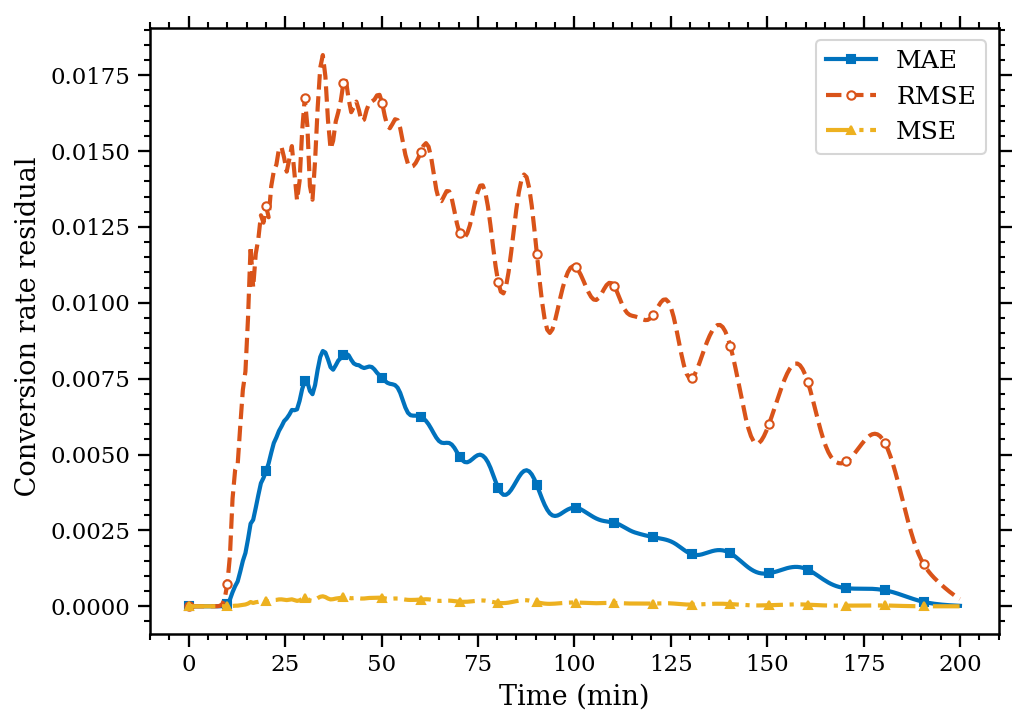

CNN -> DAEM Physics/Reconstruction Error
Overall MAE  : 3.10035120e-03
Overall MSE  : 1.10587527e-04
Overall RMSE : 1.05160605e-02


In [ ]:

# CNN Physics / DAEM Reconstruction Residual vs Time
# Uses CNN-predicted physical kinetic parameters






logA = cnn_params_phys[:, [0, 3, 6]]
E = cnn_params_phys[:, [1, 4, 7]] * 1000.0   # kJ/mol -> J/mol
c = cnn_params_phys[:, [2, 5, 8]]

A = 10.0 ** logA

trunk_phys = trunk_norm * trunk_std + trunk_mean

t = trunk_phys[:, :, 0]
beta = trunk_phys[:, :, 1]

R = 8.314
T0 = 273.15

T = T0 + beta[:, :, None] * t[:, :, None]


# 4. Reshape parameters

A = A[:, None, :]
E = E[:, None, :]
c = c[:, None, :]

# 5. DAEM reconstruction from CNN predicted parameters

k = A * np.exp(-E / (R * T))

dt = t[:, 1:] - t[:, :-1]

k_avg = 0.5 * (k[:, 1:, :] + k[:, :-1, :])
integ_step = k_avg * dt[:, :, None]

integ = np.cumsum(integ_step, axis=1)
zero = np.zeros_like(integ[:, :1, :])
integ = np.concatenate([zero, integ], axis=1)

alpha_i = 1.0 - np.exp(-integ)
alpha_daem_cnn = np.sum(c * alpha_i, axis=-1)
alpha_daem_cnn = np.clip(alpha_daem_cnn, 0.0, 1.0)


# 6. Residual against true test alpha

physics_residual_cnn = alpha_daem_cnn - alpha_true

physics_mae_cnn = np.mean(np.abs(physics_residual_cnn), axis=0)
physics_mse_cnn = np.mean(physics_residual_cnn ** 2, axis=0)
physics_rmse_cnn = np.sqrt(physics_mse_cnn)


# 7. Plot

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    t_grid,
    physics_mae_cnn,
    color="#0072BD",
    lw=2.0,
    marker="s",
    markersize=4,
    markevery=15,
    label="MAE"
)

ax.plot(
    t_grid,
    physics_rmse_cnn,
    color="#D95319",
    lw=2.0,
    ls="--",
    marker="o",
    markersize=4,
    markerfacecolor="white",
    markeredgecolor="#D95319",
    markevery=15,
    label="RMSE"
)

ax.plot(
    t_grid,
    physics_mse_cnn,
    color="#EDB120",
    lw=2.0,
    ls="-.",
    marker="^",
    markersize=4,
    markevery=15,
    label="MSE"
)

ax.set_xlabel("Time (min)")
ax.set_ylabel(" Conversion rate residual")

origin_axes(ax)
ax.legend(loc="best")

fig.tight_layout()

fig.savefig(
    os.path.join(SAVE_DIR, "CNN_DAEM_physics_convertion_rate_residual_vs_time.png"),
    dpi=600,
    bbox_inches="tight",
    transparent=False,
    facecolor="white"
)

plt.show()


# 8. Overall metrics

overall_mae = np.mean(np.abs(physics_residual_cnn))
overall_mse = np.mean(physics_residual_cnn ** 2)
overall_rmse = np.sqrt(overall_mse)

print("=" * 60)
print("CNN -> DAEM Physics/Reconstruction Error")
print("=" * 60)
print(f"Overall MAE  : {overall_mae:.8e}")
print(f"Overall MSE  : {overall_mse:.8e}")
print(f"Overall RMSE : {overall_rmse:.8e}")
print("=" * 60)

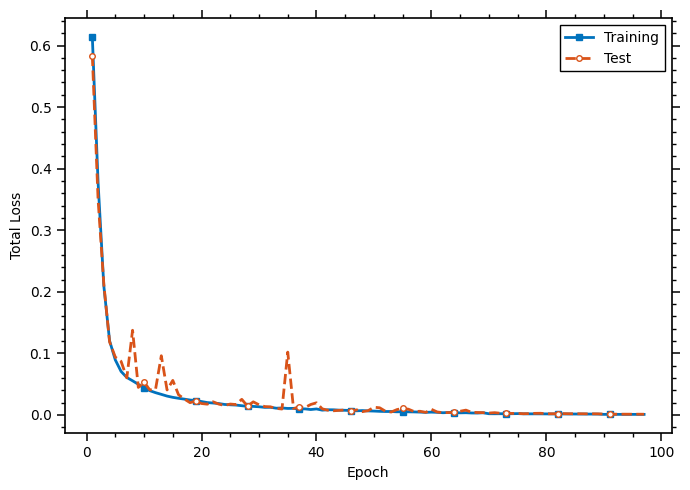

In [ ]:

# CNN INVERSE: Total Loss vs Epoch — Origin-style

history = checkpoint["history"]

train_losses = history["train_total"]
val_losses = history["test_total"]

epochs = np.arange(1, len(train_losses) + 1)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    epochs,
    train_losses,
    color="#0072BD",
    lw=2.0,
    marker="s",
    markersize=4,
    markevery=max(1, len(epochs)//10),
    label="Training"
)

ax.plot(
    epochs,
    val_losses,
    color="#D95319",
    lw=2.0,
    ls="--",
    marker="o",
    markersize=4,
    markerfacecolor="white",
    markeredgecolor="#D95319",
    markevery=max(1, len(epochs)//10),
    label="Test"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Total Loss")

origin_axes(ax)

leg = ax.legend(
    loc="best",
    frameon=True,
    fancybox=False,
    edgecolor="black",
    facecolor="white",
    framealpha=1.0
)

leg.get_frame().set_linewidth(1.0)

fig.tight_layout()

fig.savefig(
    os.path.join(
        SAVE_DIR,
        "CNN_inverse_total_loss_vs_epoch_origin.png"
    ),
    dpi=600,
    bbox_inches="tight",
    transparent=False,
    facecolor="white"
)

plt.show()



In [ ]:

# CNN INVERSE MODEL: PARAMETER COMPARISON TABLE AT beta = 21
# For selected alpha values

BETA_TARGET = 21.0
SAMPLE_SEED = 2026

alpha_grid = np.array([
    0.10, 0.15, 0.20, 0.25, 0.30, 0.35,
    0.40, 0.45, 0.50, 0.55, 0.60, 0.65,
    0.70, 0.75, 0.80, 0.85, 0.90
])

# ------------------------------------------------------------
# Get all test predictions first
# ------------------------------------------------------------
inverse_model.eval()

loader = DataLoader(
    test_dataset,
    batch_size=4096,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

all_alpha = []
all_trunk = []
all_branch_true = []
all_branch_pred = []

with torch.no_grad():
    for trunk_norm, beta_ids, alpha_true, branch_true_norm, branch_true_phys in loader:

        trunk_norm = trunk_norm.to(device)
        alpha_true = alpha_true.to(device)

        branch_pred_norm, branch_pred_phys = inverse_model(
            trunk_norm,
            alpha_true
        )

        all_alpha.append(alpha_true.cpu().numpy())
        all_trunk.append(trunk_norm.cpu().numpy())
        all_branch_true.append(branch_true_phys.numpy())
        all_branch_pred.append(branch_pred_phys.cpu().numpy())

alpha_all = np.concatenate(all_alpha, axis=0)
trunk_all = np.concatenate(all_trunk, axis=0)
branch_true_all = np.concatenate(all_branch_true, axis=0)
branch_pred_all = np.concatenate(all_branch_pred, axis=0)


# Recover beta values

trunk_phys_all = trunk_all * trunk_std + trunk_mean
beta_all = trunk_phys_all[:, :, 1].mean(axis=1)

beta_indices = np.where(np.isclose(beta_all, BETA_TARGET, atol=1e-4))[0]

if len(beta_indices) == 0:
    raise ValueError(f"No test samples found for beta={BETA_TARGET}")


# Pick one reproducible test sample at beta=21

rng = np.random.default_rng(SAMPLE_SEED)
sample_idx = rng.choice(beta_indices)

alpha_curve = alpha_all[sample_idx]
target_params = branch_true_all[sample_idx].copy()
pred_params = branch_pred_all[sample_idx].copy()

# E is already in kJ/mol in your branch format.
# Do NOT divide by 1000.

print("Selected test sample index:", sample_idx)
print("Beta:", beta_all[sample_idx])
print("Alpha range:", alpha_curve.min(), "to", alpha_curve.max())


# Build table
# Since one sample has one fixed parameter set,
# target/pred parameters repeat for each alpha.

param_names = [
    "logA1", "E1_kJ_mol", "c1",
    "logA2", "E2_kJ_mol", "c2",
    "logA3", "E3_kJ_mol", "c3"
]

rows = []

for alpha_value in alpha_grid:

    # Find nearest time point to this alpha value
    nearest_t_idx = np.argmin(np.abs(alpha_curve - alpha_value))

    actual_alpha = alpha_curve[nearest_t_idx]
    time_at_alpha = t_grid[nearest_t_idx]

    row = {
        "requested_alpha": alpha_value,
        "actual_alpha_nearest": actual_alpha,
        "time_min": time_at_alpha,
        "beta": beta_all[sample_idx],
    }

    for j, name in enumerate(param_names):
        row[f"{name}_target"] = target_params[j]
        row[f"{name}_pred"] = pred_params[j]
        row[f"{name}_abs_error"] = abs(pred_params[j] - target_params[j])

    # For one sample, R2 across all 9 parameters
    row["R2_all_9_params"] = r2_score(
        target_params.reshape(-1),
        pred_params.reshape(-1)
    )

    row["SE_all_9_params"] = np.std(
        pred_params - target_params,
        ddof=1
    ) / np.sqrt(len(target_params))

    rows.append(row)

one_sample_df = pd.DataFrame(rows)

save_path = os.path.join(
    SAVE_DIR,
    f"one_sample_beta_{int(BETA_TARGET)}_parameter_table_vs_alpha.csv"
)

one_sample_df.to_csv(save_path, index=False)

print("Saved table to:", save_path)

one_sample_df

Selected test sample index: 95903
Beta: 21.0
Alpha range: 0.0 to 1.0
Saved table to: /content/drive/MyDrive/PI_DeepONet_Checkpoints/one_sample_beta_21_parameter_table_vs_alpha.csv


,requested_alpha,actual_alpha_nearest,time_min,beta,logA1_target,logA1_pred,logA1_abs_error,E1_kJ_mol_target,E1_kJ_mol_pred,E1_kJ_mol_abs_error,...,logA3_pred,logA3_abs_error,E3_kJ_mol_target,E3_kJ_mol_pred,E3_kJ_mol_abs_error,c3_target,c3_pred,c3_abs_error,R2_all_9_params,SE_all_9_params
0,0.10,0.099995,38.795987,21.0,12.8,12.765702,0.034298,252.0,251.775009,0.224991,...,10.001765,0.001765,360.0,358.387177,1.612823,0.8,0.778604,0.021396,0.999962,0.277295
1,0.15,0.155124,54.849498,21.0,12.8,12.765702,0.034298,252.0,251.775009,0.224991,...,10.001765,0.001765,360.0,358.387177,1.612823,0.8,0.778604,0.021396,0.999962,0.277295
2,0.20,0.200307,58.193980,21.0,12.8,12.765702,0.034298,252.0,251.775009,0.224991,...,10.001765,0.001765,360.0,358.387177,1.612823,0.8,0.778604,0.021396,0.999962,0.277295
3,0.25,0.253067,64.214047,21.0,12.8,12.765702,0.034298,252.0,251.775009,0.224991,...,10.001765,0.001765,360.0,358.387177,1.612823,0.8,0.778604,0.021396,0.999962,0.277295
4,0.30,0.305749,66.220736,21.0,12.8,12.765702,0.034298,252.0,251.775009,0.224991,...,10.001765,0.001765,360.0,358.387177,1.612823,0.8,0.778604,0.021396,0.999962,0.277295
5,0.35,0.361532,67.558528,21.0,12.8,12.765702,0.034298,252.0,251.775009,0.224991,...,10.001765,0.001765,360.0,358.387177,1.612823,0.8,0.778604,0.021396,0.999962,0.277295
6,0.40,0.397122,68.227425,21.0,12.8,12.765702,0.034298,252.0,251.775009,0.224991,...,10.001765,0.001765,360.0,358.387177,1.612823,0.8,0.778604,0.021396,0.999962,0.277295
7,0.45,0.438260,68.896321,21.0,12.8,12.765702,0.034298,252.0,251.775009,0.224991,...,10.001765,0.001765,360.0,358.387177,1.612823,0.8,0.778604,0.021396,0.999962,0.277295
8,0.50,0.484961,69.565217,21.0,12.8,12.765702,0.034298,252.0,251.775009,0.224991,...,10.001765,0.001765,360.0,358.387177,1.612823,0.8,0.778604,0.021396,0.999962,0.277295
9,0.55,0.536871,70.234114,21.0,12.8,12.765702,0.034298,252.0,251.775009,0.224991,...,10.001765,0.001765,360.0,358.387177,1.612823,0.8,0.778604,0.021396,0.999962,0.277295



Preparing real TGA curves
beta=5: T=400.0-900.0 C, W=94.6100->84.6100 %, loss=10.0000 %, alpha=0.000->1.000
beta=15: T=400.0-899.9 C, W=92.1800->82.2400 %, loss=9.9400 %, alpha=0.000->1.000
beta=25: T=400.1-899.9 C, W=92.0400->82.1900 %, loss=9.8500 %, alpha=0.000->1.000

Initial shared guess from inverse model:
Comp 1: logA=10.00557, E=192.11336 kJ/mol, c=0.49019
Comp 2: logA=15.70565, E=235.75922 kJ/mol, c=0.30854
Comp 3: logA=14.87665, E=324.46478 kJ/mol, c=0.20126
c sum: 1.0000001

Fitting one shared kinetic parameter set
step=   1 loss=2.116916e-03 data=2.116916e-03
step= 500 loss=3.354156e-04 data=3.331121e-04
step=1000 loss=3.354143e-04 data=3.331184e-04
step=1500 loss=3.354142e-04 data=3.331189e-04
step=2000 loss=3.354145e-04 data=3.331194e-04
step=2500 loss=3.354142e-04 data=3.331196e-04
step=3000 loss=3.354142e-04 data=3.331197e-04

KINETIC PARAMETER OPTIMIZATION TIME
Time required: 13.95 seconds
Time required: 0.23 minutes

FINAL GLOBAL KINETIC PARAMETERS
Component | logA  

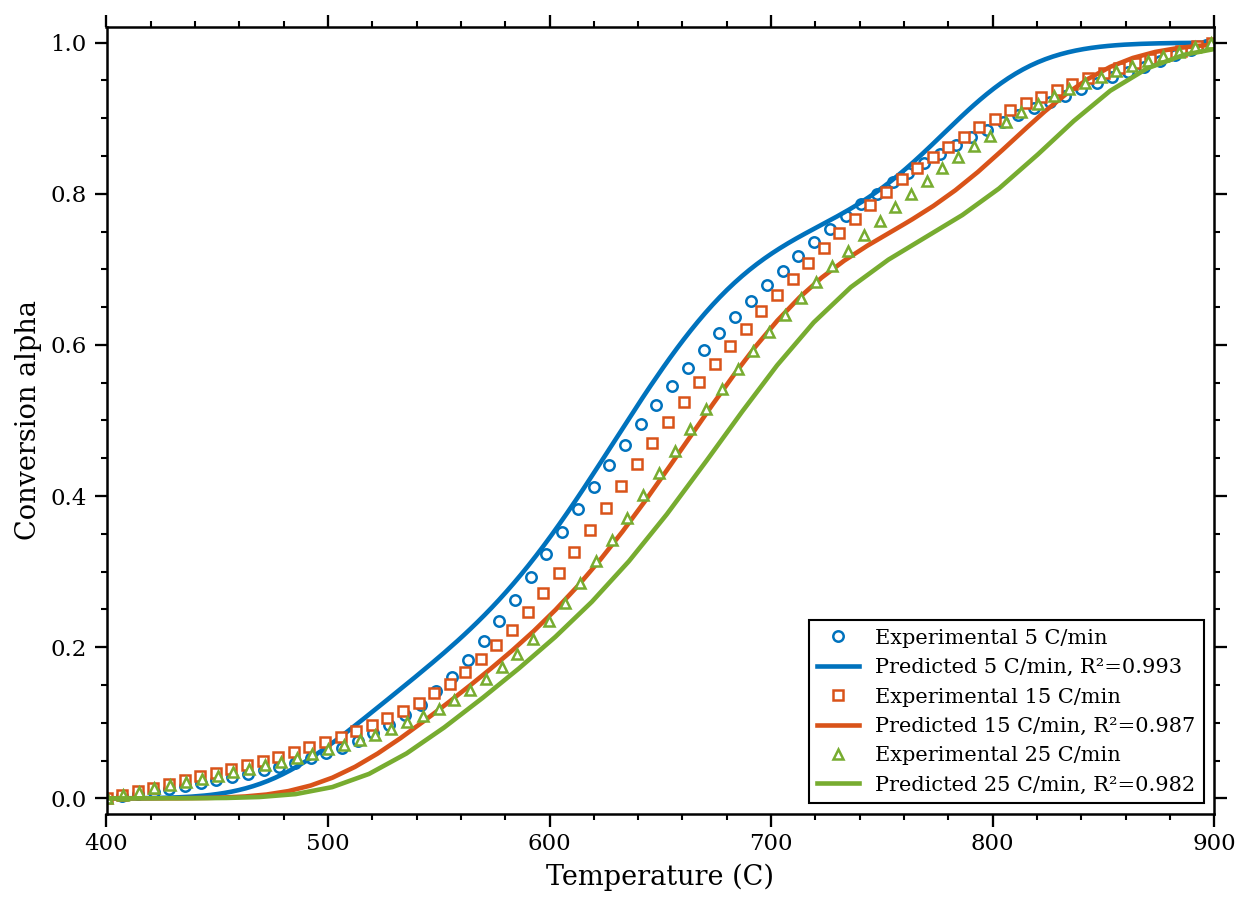


Global fit metrics
Beta | R²       | RMSE     | MAE
-------------------------------------------------------
   5 |  0.99259 |  0.03105 |  0.02649
  15 |  0.98700 |  0.04108 |  0.03636
  25 |  0.98158 |  0.04890 |  0.04374

Saved figure to: /content/drive/MyDrive/PI_DeepONet_Checkpoints/real_data_coconut_origin_600dpi.png
Kinetic calculation time: 13.95 seconds


In [ ]:

# REAL TGA GLOBAL KINETIC FIT: ONE PARAMETER SET FOR 5/15/25 C/min



FILES = {
    5:  "coconut shell 5 C min.xlsx",
    15: "coconut shell 15 C min.xlsx",
    25: "coconut shell 25 C min.xlsx",
}

COLUMN_TIME = "Time"
COLUMN_TEMP = "Temperature"
COLUMN_WEIGHT = "Weight"
COLUMN_DTG = "Deriv. Weight"

TEMP_WINDOW = (400, 900)   # main decomposition window from inspection
T0_MODEL = 273.15
N_TIME = 300
TIME_MAX = 200

t_grid = np.linspace(0, TIME_MAX, N_TIME).astype(np.float32)


# Origin-like plot style
-
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 12,
    "axes.linewidth": 1.2,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 150,
    "savefig.dpi": 600,
})

origin_colors = {
    5: "#0072BD",
    15: "#D95319",
    25: "#77AC30",
}

def origin_axes(ax):
    ax.grid(False)

    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.2)
        ax.spines[side].set_color("black")

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=6,
        width=1.1,
        top=True,
        right=True
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="out",
        length=3,
        width=1.0,
        top=True,
        right=True
    )

    ax.minorticks_on()


# Helpers

def clean_tga_excel(path):
    df = pd.read_excel(path)
    df.columns = [str(c).strip() for c in df.columns]

    required = [COLUMN_TIME, COLUMN_TEMP, COLUMN_WEIGHT, COLUMN_DTG]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{path}: missing columns {missing}. Found {list(df.columns)}")

    df = df[required].copy()

    for col in required:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(",", "", regex=False).str.strip(),
            errors="coerce"
        )

    df = df.dropna(subset=required).copy()
    df = df.sort_values(COLUMN_TEMP).reset_index(drop=True)
    return df


def alpha_from_weight(W):
    W = np.asarray(W, dtype=np.float32)
    w0 = float(W[0])
    wf = float(W[-1])

    if abs(w0 - wf) < 1e-12:
        raise ValueError("w0 and wf are too close; cannot compute alpha.")

    alpha = (w0 - W) / (w0 - wf)
    alpha = np.clip(alpha, 0.0, 1.0)
    alpha = np.maximum.accumulate(alpha)
    return alpha.astype(np.float32), w0, wf


def prepare_windowed_curve(beta, path, temp_window):
    df = clean_tga_excel(path)

    T = df[COLUMN_TEMP].to_numpy(dtype=np.float32)       # Celsius
    W = df[COLUMN_WEIGHT].to_numpy(dtype=np.float32)     # %
    DTG = df[COLUMN_DTG].to_numpy(dtype=np.float32)
    time = df[COLUMN_TIME].to_numpy(dtype=np.float32)

    lo, hi = temp_window
    mask = (T >= lo) & (T <= hi)

    if mask.sum() < 20:
        raise ValueError(f"beta={beta}: too few points in window {lo}-{hi} C.")

    T_win = T[mask]
    W_win = W[mask]
    DTG_win = DTG[mask]
    time_win = time[mask]

    alpha_win, w0, wf = alpha_from_weight(W_win)

    # Model used T(K)=273.15+beta*t, so Celsius T = beta*t.
    time_model = T_win / float(beta)

    time_unique, unique_idx = np.unique(time_model, return_index=True)
    alpha_unique = alpha_win[unique_idx]

    alpha_interp = np.interp(
        t_grid,
        time_unique,
        alpha_unique,
        left=alpha_unique[0],
        right=alpha_unique[-1]
    ).astype(np.float32)

    trunk_phys = np.column_stack([
        t_grid,
        np.full_like(t_grid, float(beta), dtype=np.float32)
    ]).astype(np.float32)

    trunk_norm_np = (trunk_phys - trunk_mean) / trunk_std

    print(
        f"beta={beta}: T={T_win[0]:.1f}-{T_win[-1]:.1f} C, "
        f"W={w0:.4f}->{wf:.4f} %, loss={w0-wf:.4f} %, "
        f"alpha={alpha_win[0]:.3f}->{alpha_win[-1]:.3f}"
    )

    return {
        "beta": beta,
        "T_exp": T_win,
        "W_exp": W_win,
        "DTG_exp": DTG_win,
        "time_exp": time_win,
        "time_model": time_model.astype(np.float32),
        "alpha_exp": alpha_win,
        "alpha_interp": alpha_interp,
        "trunk_norm_np": trunk_norm_np,
        "w0": w0,
        "wf": wf,
    }


def pack_branch_phys(logA, E, c):
    branch_phys = torch.zeros((1, 9), dtype=logA.dtype, device=logA.device)
    branch_phys[:, [0, 3, 6]] = logA
    branch_phys[:, [1, 4, 7]] = E
    branch_phys[:, [2, 5, 8]] = c
    return branch_phys


--
# Prepare real curves

real_results = []

print("\nPreparing real TGA curves")
print("=" * 70)

for beta, path in FILES.items():
    real_results.append(prepare_windowed_curve(beta, path, TEMP_WINDOW))

# Initial guess from inverse model for each beta, then average

inverse_core = inverse_model._orig_mod if hasattr(inverse_model, "_orig_mod") else inverse_model

init_branches = []

with torch.no_grad():
    inverse_model.eval()

    for r in real_results:
        trunk_tensor = torch.tensor(
            r["trunk_norm_np"][None, :, :],
            dtype=torch.float32,
            device=device
        )

        alpha_tensor = torch.tensor(
            r["alpha_interp"][None, :],
            dtype=torch.float32,
            device=device
        )

        _, branch_phys = inverse_model(trunk_tensor, alpha_tensor)
        init_branches.append(branch_phys.squeeze(0).detach().cpu().numpy())

init_branches = np.array(init_branches)
branch_init_np = np.mean(init_branches, axis=0).astype(np.float32)

# Re-normalize c exactly
c_init = branch_init_np[[2, 5, 8]]
c_init = np.clip(c_init, 1e-6, None)
c_init = c_init / c_init.sum()
branch_init_np[[2, 5, 8]] = c_init

print("\nInitial shared guess from inverse model:")
for j in range(3):
    print(
        f"Comp {j+1}: logA={branch_init_np[3*j+0]:.5f}, "
        f"E={branch_init_np[3*j+1]:.5f} kJ/mol, "
        f"c={branch_init_np[3*j+2]:.5f}"
    )
print("c sum:", branch_init_np[[2, 5, 8]].sum())

# Optimize ONE shared branch parameter set against all 3 curves

branch_mean_t = torch.tensor(branch_mean, dtype=torch.float32, device=device)
branch_std_t = torch.tensor(branch_std, dtype=torch.float32, device=device)

p0 = torch.tensor(branch_init_np[None, :], dtype=torch.float32, device=device)

logA0 = p0[:, [0, 3, 6]]
E0 = p0[:, [1, 4, 7]]
c0 = p0[:, [2, 5, 8]]

logA_min = inverse_core.logA_min.detach().to(device)
logA_max = inverse_core.logA_max.detach().to(device)
E_min = inverse_core.E_min.detach().to(device)
E_max = inverse_core.E_max.detach().to(device)

eps = 1e-5

logA_scaled = ((logA0 - logA_min) / (logA_max - logA_min)).clamp(eps, 1 - eps)
E_scaled = ((E0 - E_min) / (E_max - E_min)).clamp(eps, 1 - eps)

raw_logA = torch.logit(logA_scaled).detach().clone().requires_grad_(True)
raw_E = torch.logit(E_scaled).detach().clone().requires_grad_(True)
raw_c = torch.log(c0.clamp_min(eps)).detach().clone().requires_grad_(True)

trunk_tensors = [
    torch.tensor(r["trunk_norm_np"][None, :, :], dtype=torch.float32, device=device)
    for r in real_results
]

alpha_targets = [
    torch.tensor(r["alpha_interp"][None, :], dtype=torch.float32, device=device)
    for r in real_results
]

forward_model.eval()
for p in forward_model.parameters():
    p.requires_grad = False

optimizer = torch.optim.AdamW([raw_logA, raw_E, raw_c], lr=0.03, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=5000,
    eta_min=0.001
)

best_loss = float("inf")
best_branch = None
best_alpha_grids = None

print("\nFitting one shared kinetic parameter set")
print("=" * 70)


# START TIMING

kinetics_start_time = time.perf_counter()

for step in range(1, 3001):
    optimizer.zero_grad(set_to_none=True)

    logA = logA_min + (logA_max - logA_min) * torch.sigmoid(raw_logA)
    E = E_min + (E_max - E_min) * torch.sigmoid(raw_E)
    c = torch.softmax(raw_c, dim=1)

    branch_phys = pack_branch_phys(logA, E, c)
    branch_norm = (branch_phys - branch_mean_t) / branch_std_t

    losses = []
    alpha_grids = []

    for trunk_tensor, alpha_target in zip(trunk_tensors, alpha_targets):
        alpha_pred = forward_model(branch_norm, trunk_tensor).squeeze(-1)
        losses.append(F.mse_loss(alpha_pred, alpha_target))
        alpha_grids.append(alpha_pred)

    loss_data = torch.stack(losses).mean()

    # small regularization: keeps fit near neural inverse guess, but weak enough to move
    loss_reg = 1e-5 * F.mse_loss(branch_phys, p0)

    loss = loss_data + loss_reg

    loss.backward()
    optimizer.step()
    scheduler.step()

    if loss.item() < best_loss:
        best_loss = loss.item()
        best_branch = branch_phys.detach().clone()
        best_alpha_grids = [a.detach().clone() for a in alpha_grids]

    if step == 1 or step % 500 == 0:
        print(
            f"step={step:4d} loss={loss.item():.6e} "
            f"data={loss_data.item():.6e}"
        )
# END TIMING AND PRINT

kinetics_elapsed_seconds = time.perf_counter() - kinetics_start_time

print()
print("=" * 70)
print("KINETIC PARAMETER OPTIMIZATION TIME")
print("=" * 70)
print(f"Time required: {kinetics_elapsed_seconds:.2f} seconds")
print(f"Time required: {kinetics_elapsed_seconds / 60.0:.2f} minutes")

branch_fit = best_branch.squeeze(0).cpu().numpy()
alpha_fit_grids = [a.squeeze(0).cpu().numpy() for a in best_alpha_grids]

for r, alpha_grid in zip(real_results, alpha_fit_grids):
    r["alpha_fit_grid"] = alpha_grid


# Print final kinetic parameters

print("\n" + "=" * 70)
print("FINAL GLOBAL KINETIC PARAMETERS")
print("=" * 70)
print("Component | logA        | E (kJ/mol)  | c")
print("-" * 48)

for j in range(3):
    print(
        f"{j+1:9d} | "
        f"{branch_fit[3*j+0]:10.5f} | "
        f"{branch_fit[3*j+1]:10.5f} | "
        f"{branch_fit[3*j+2]:8.5f}"
    )

print(f"c sum = {branch_fit[[2, 5, 8]].sum():.6f}")


# Plot fit against experimental data - Origin style

fig, ax = plt.subplots(figsize=(8.5, 6.2))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

markers = {
    5: "o",
    15: "s",
    25: "^",
}

metrics_rows = []

for r in real_results:
    beta = r["beta"]
    color = origin_colors.get(beta, "#0072BD")
    marker = markers.get(beta, "o")

    alpha_fit_at_exp = np.interp(
        r["time_model"],
        t_grid,
        r["alpha_fit_grid"]
    )

    r2_beta = r2_score(r["alpha_exp"], alpha_fit_at_exp)
    rmse_beta = np.sqrt(mean_squared_error(r["alpha_exp"], alpha_fit_at_exp))
    mae_beta = mean_absolute_error(r["alpha_exp"], alpha_fit_at_exp)
    metrics_rows.append((beta, r2_beta, rmse_beta, mae_beta))

    # Plot experimental points
    # About 60-80 experimental markers
    mark_every = max(1, len(r["T_exp"]) // 70)

# Plot experimental conversion points
    ax.plot(
      r["T_exp"],
      r["alpha_exp"],
      linestyle="none",
      marker=marker,
      markersize=5,
      markerfacecolor="white",
      markeredgecolor=color,
      markeredgewidth=1.2,
      markevery=mark_every,
      label=f"Experimental {beta:g} C/min"
      )

    # Plot fitted curve
    ax.plot(
        r["T_exp"],
        alpha_fit_at_exp,
        color=color,
        lw=2.2,
        linestyle="-",
        label=f"Predicted {beta:g} C/min, R²={r2_beta:.3f}"
    )

ax.set_xlabel("Temperature (C)")
ax.set_ylabel("Conversion alpha")
ax.set_xlim(TEMP_WINDOW[0], TEMP_WINDOW[1])
ax.set_ylim(-0.02, 1.02)

origin_axes(ax)

leg = ax.legend(
    loc="lower right",
    frameon=True,
    fancybox=False,
    edgecolor="black",
    facecolor="white",
    framealpha=1.0
)
leg.get_frame().set_linewidth(1.0)

fig.tight_layout()

SAVE_FIG_PATH = os.path.join(
    SAVE_DIR,
    "real_data_coconut_origin_600dpi.png"
)

fig.savefig(
    SAVE_FIG_PATH,
    dpi=600,
    bbox_inches="tight",
    transparent=False,
    facecolor="white"
)

plt.show()

print("\nGlobal fit metrics")
print("=" * 55)
print("Beta | R²       | RMSE     | MAE")
print("-" * 55)
for beta, r2_beta, rmse_beta, mae_beta in metrics_rows:
    print(f"{beta:4g} | {r2_beta:8.5f} | {rmse_beta:8.5f} | {mae_beta:8.5f}")

print("\nSaved figure to:", SAVE_FIG_PATH)
print(f"Kinetic calculation time: {kinetics_elapsed_seconds:.2f} seconds")